# MScFE 642 — Deep Learning for Finance
## Group Work Project #1 | Steps 1–3

---

| Field | Detail |
|---|---|
| **Course** | MScFE 642 — Deep Learning for Finance |
| **Assignment** | Group Work Project #1 |
| **Scope** | Steps 1 (EDA), 2 (MLP), 3 (CNN-GAF) |
| **Asset Universe** | SPY · TLT · SHY · GLD · DBO |
| **Test Period** | 2018-01-01 → 2022-12-30 |

---

### Executive Overview

This notebook constitutes the quantitative backbone of a multi-asset deep learning study.
We progressively construct three model families — **Multilayer Perceptron (MLP)**,
and **Convolutional Neural Network operating on Gramian Angular Field (CNN-GAF)** images —
each designed to generate **25-day-ahead return forecasts** for five ETFs spanning
equities (SPY), long-duration Treasuries (TLT), short-duration Treasuries (SHY),
gold (GLD), and crude oil (DBO).

The notebook is structured as follows:

* **Step 1** — Data acquisition, feature engineering, and comprehensive exploratory data analysis (EDA).
* **Step 2** — Five univariate MLP regressors, one per ETF, with in-sample and out-of-sample evaluation.
* **Step 3** — Five CNN regressors trained on GAF image representations, with cross-architecture comparison.

> **Reproducibility note:** A global random seed (`SEED = 42`) is set at the top of the notebook.
> All results should be fully reproducible in a clean Python 3.10+ environment with the packages
> listed in the first code cell.

In [ ]:
!pip -q install yfinance statsmodels

---
## 0 · Environment Setup

We pin library versions and configure global random seeds across NumPy, Python's `random`
module, and TensorFlow to guarantee deterministic training runs. Warnings are suppressed
to keep output focused on analytical content.

In [ ]:
# ── 0.1  Standard library & warnings ──────────────────────────────────────
import os, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

SEED = 42
random.seed(SEED)

# ── 0.2  Numerical & data ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
np.random.seed(SEED)

# ── 0.3  Visualisation ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
PALETTE = ['#2196F3','#E53935','#43A047','#FB8C00','#8E24AA']   # blue·red·green·orange·purple

# ── 0.4  Finance & statistics ────────────────────────────────────────────
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# ── 0.5  Machine learning ─────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── 0.6  Deep learning ────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# ── 0.7  GAF (Gramian Angular Field) ─────────────────────────────────────
!pip install pyts
from pyts.image import GramianAngularField

print(f"NumPy     {np.__version__}")
print(f"Pandas    {pd.__version__}")
print(f"TF/Keras  {tf.__version__}")
print(f"Seed      {SEED}  — all RNGs configured.")

NumPy     2.0.2
Pandas    2.2.2
TF/Keras  2.20.0
Seed      42  — all RNGs configured.


---
# STEP 1 — Data Acquisition & Exploratory Data Analysis

### 1.1  Asset universe and sample design

We study five exchange-traded funds (ETFs) that proxy the five major liquid asset classes
available to institutional investors:

| Symbol | Fund | Asset Class | Benchmark |
|--------|------|-------------|----------|
| **SPY** | SPDR S&P 500 ETF Trust | Equities | S&P 500 |
| **TLT** | iShares 20+ Year Treasury Bond ETF | Fixed Income (long) | ICE US Treasury 20+ yr |
| **SHY** | iShares 1–3 Year Treasury Bond ETF | Cash-like / Short Duration | ICE US Treasury 1–3 yr |
| **GLD** | SPDR Gold Shares | Precious Metals | Gold spot |
| **DBO** | Invesco DB Oil Fund | Commodities (Crude Oil) | DBIQ Optimum Yield Crude Oil |

**Sample periods:**

| Split | Start | End | Rationale |
|-------|-------|-----|-----------|
| Training | 2010-01-04 | 2016-12-30 | ~7 years; rich regime variety (post-GFC recovery, taper tantrum, China shock) |
| Validation | 2017-01-02 | 2017-12-29 | 1 year; used for early stopping and hyperparameter tuning |
| Test | 2018-01-01 | 2022-12-30 | **Fixed by assignment**; covers COVID crash, rate hike cycle |

Starting the training window in 2010 provides approximately 1,750 daily observations for
learning — sufficient for deep learning models — while still capturing multiple distinct
macro regimes.

In [ ]:
# ── 1.1  Define universe and sample boundaries ─────────────────────────────
TICKERS  = ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
LABELS   = {
    'SPY': 'Equity (SPY)',
    'TLT': 'Long Bond (TLT)',
    'SHY': 'Short Bond (SHY)',
    'GLD': 'Gold (GLD)',
    'DBO': 'Crude Oil (DBO)',
}

TRAIN_START = '2007-01-01'
TRAIN_END   = '2016-12-31'
VAL_START   = '2017-01-01'
VAL_END     = '2017-12-31'
TEST_START  = '2018-01-01'
TEST_END    = '2022-12-31'
FULL_START  = TRAIN_START
FULL_END    = TEST_END

HORIZON = 25   # forward-return horizon (trading days)

print("Asset universe :", TICKERS)
print(f"Training        : {TRAIN_START}  →  {TRAIN_END}")
print(f"Validation      : {VAL_START}  →  {VAL_END}")
print(f"Test (fixed)    : {TEST_START}  →  {TEST_END}")
print(f"Prediction horizon : {HORIZON} trading days")

Asset universe : ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
Training        : 2007-01-01  →  2016-12-31
Validation      : 2017-01-01  →  2017-12-31
Test (fixed)    : 2018-01-01  →  2022-12-31
Prediction horizon : 25 trading days


In [ ]:
# ── 1.2  Download adjusted closing prices via yfinance ─────────────────────
raw = yf.download(
    tickers   = TICKERS,
    start     = FULL_START,
    end       = FULL_END,
    auto_adjust = True,
    progress  = False,
)['Close']

raw = raw[TICKERS]                   # ensure column order
raw.index = pd.to_datetime(raw.index).tz_localize(None)
raw.index.name = 'Date'

print(f"Price matrix shape : {raw.shape}  ({raw.index[0].date()} → {raw.index[-1].date()})")
print(f"Missing values     : {raw.isnull().sum().to_dict()}")
raw.tail(3)

Price matrix shape : (4028, 5)  (2007-01-03 → 2022-12-30)
Missing values     : {'SPY': 0, 'TLT': 0, 'SHY': 0, 'GLD': 0, 'DBO': 2}


Ticker,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2022-12-28,361.0841,86.8315,71.8841,167.9100,13.1782
2022-12-29,367.5837,87.8171,71.9372,168.8500,13.1165
2022-12-30,366.6155,86.8402,71.8487,169.6400,13.4074


In [ ]:
# ── 1.3  Derive return series ──────────────────────────────────────────────
# Daily log-returns: r_t = ln(P_t / P_{t-1})
# Log-returns are additive over time, approximately normally distributed,
# and free of the unit-root present in price levels.

prices  = raw.ffill()                          # forward-fill the single NaN gaps
log_ret = np.log(prices / prices.shift(1)).dropna()

# 25-day forward log-returns (rolling sum of future daily log-returns)
fwd_ret = log_ret.rolling(HORIZON).sum().shift(-HORIZON)

print("Daily log-return matrix :")
print(log_ret.describe().round(6))

Daily log-return matrix :
Ticker        SPY        TLT        SHY        GLD        DBO
count  4,025.0000 4,025.0000 4,025.0000 4,025.0000 4,025.0000
mean       0.0003     0.0001     0.0001     0.0003    -0.0001
std        0.0129     0.0096     0.0009     0.0112     0.0202
min       -0.1159    -0.0690    -0.0066    -0.0919    -0.1821
25%       -0.0042    -0.0055    -0.0004    -0.0052    -0.0101
50%        0.0007     0.0005     0.0000     0.0005     0.0011
75%        0.0060     0.0057     0.0004     0.0059     0.0111
max        0.1356     0.0725     0.0071     0.1070     0.1010


### 1.2  Price level visualisation

The chart below displays **normalised price series** (rebased to 100 at the start of the
full sample) to allow meaningful cross-asset comparison. Key macro episodes are annotated
to contextualise model performance in later steps:

* **2018 Q4** — Fed tightening-induced equity sell-off; flight to bonds and gold.
* **2020 Q1** — COVID-19 crash: synchronised global drawdown across all risk assets.
* **2022** — Inflation shock and aggressive Fed rate hikes; equities and long bonds
  simultaneously declined (unprecedented positive equity–bond correlation).

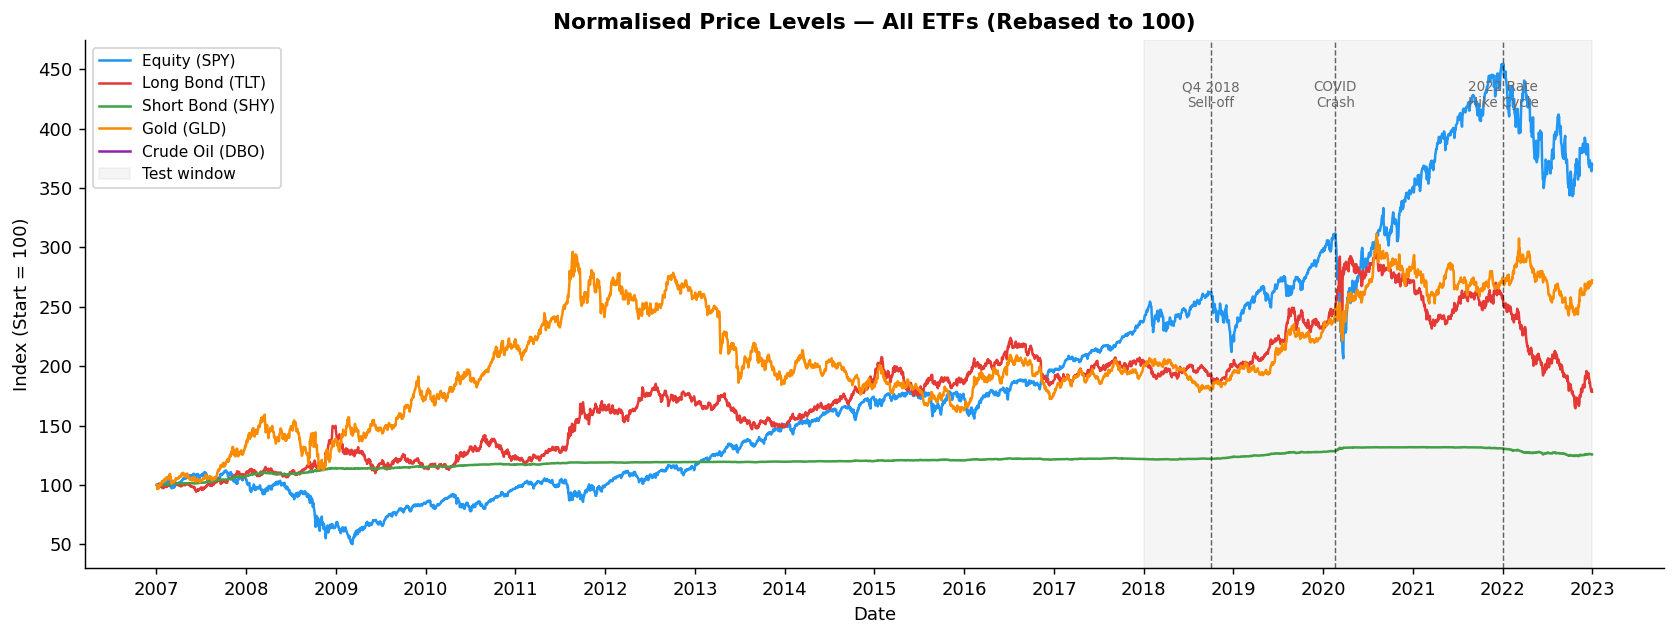

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

normed = (prices / prices.iloc[0]) * 100
for i, ticker in enumerate(TICKERS):
    ax.plot(normed.index, normed[ticker], label=LABELS[ticker],
            color=PALETTE[i], linewidth=1.4)

# Shade the test period
ax.axvspan(pd.Timestamp(TEST_START), pd.Timestamp(TEST_END),
           alpha=0.08, color='grey', label='Test window')

# Annotate events
events = [
    (pd.Timestamp('2020-02-20'), 'COVID\nCrash'),
    (pd.Timestamp('2022-01-03'), '2022 Rate\nHike Cycle'),
    (pd.Timestamp('2018-10-01'), 'Q4 2018\nSell-off'),
]
for ts, label in events:
    ax.axvline(ts, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(ts, normed.max().max() * 0.97, label, fontsize=7.5, ha='center',
            va='top', color='dimgrey')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Normalised Price Levels — All ETFs (Rebased to 100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Index (Start = 100)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=8.5)
plt.tight_layout()
plt.show()

**Observations:**
* SPY delivered the highest cumulative return over the full period but experienced the
  sharpest drawdown during the COVID crash.
* TLT was strongly negatively correlated with SPY through 2021, but this relationship
  inverted dramatically in 2022 when both assets fell simultaneously — a regime shift
  critical for multi-asset models.
* SHY exhibited near-zero volatility throughout, reflecting its cash-equivalent nature.
* GLD held value through most crises, consistent with its safe-haven role.
* DBO was the most volatile asset, driven by supply shocks and the 2020 crude oil crash.

### 1.3  Summary statistics of daily log-returns

We report annualised statistics and distributional shape metrics. Institutional
practitioners care particularly about **skewness** (asymmetry of return distribution)
and **excess kurtosis** (fat tails), both of which have direct implications for
Value-at-Risk and model risk.

In [ ]:
TRADING_DAYS = 252

def summary_stats(returns_df):
    """Compute annualised summary statistics for a return DataFrame."""
    s = pd.DataFrame(index=returns_df.columns)
    s['Mean (Ann., %)']  = returns_df.mean() * TRADING_DAYS * 100
    s['Vol (Ann., %)']   = returns_df.std()  * np.sqrt(TRADING_DAYS) * 100
    s['Sharpe (Ann.)']   = s['Mean (Ann., %)'] / s['Vol (Ann., %)']
    s['Skewness']        = returns_df.apply(stats.skew)
    s['Excess Kurtosis'] = returns_df.apply(lambda x: stats.kurtosis(x, fisher=True))
    s['Min (%)']         = returns_df.min() * 100
    s['Max (%)']         = returns_df.max() * 100
    s['Obs.']            = returns_df.count().astype(int)
    return s.round(4)

# Full-sample summary
stats_full = summary_stats(log_ret)
stats_full.index = [LABELS[t] for t in TICKERS]
print("─── Full-Sample Summary Statistics (Daily Log-Returns) ───")
stats_full

─── Full-Sample Summary Statistics (Daily Log-Returns) ───


,"Mean (Ann., %)","Vol (Ann., %)",Sharpe (Ann.),Skewness,Excess Kurtosis,Min (%),Max (%),Obs.
Equity (SPY),8.2257,20.5086,0.4011,-0.3590,13.1032,-11.5887,13.5577,4025
Long Bond (TLT),3.6228,15.2064,0.2382,0.0182,3.6348,-6.9010,7.2502,4025
Short Bond (SHY),1.4349,1.4008,1.0243,-0.0008,7.6740,-0.6589,0.7069,4025
Gold (GLD),6.4894,17.7163,0.3663,-0.2531,6.5702,-9.1905,10.6974,4025
Crude Oil (DBO),-2.4076,32.0847,-0.0750,-0.5671,4.6405,-18.2065,10.0955,4025


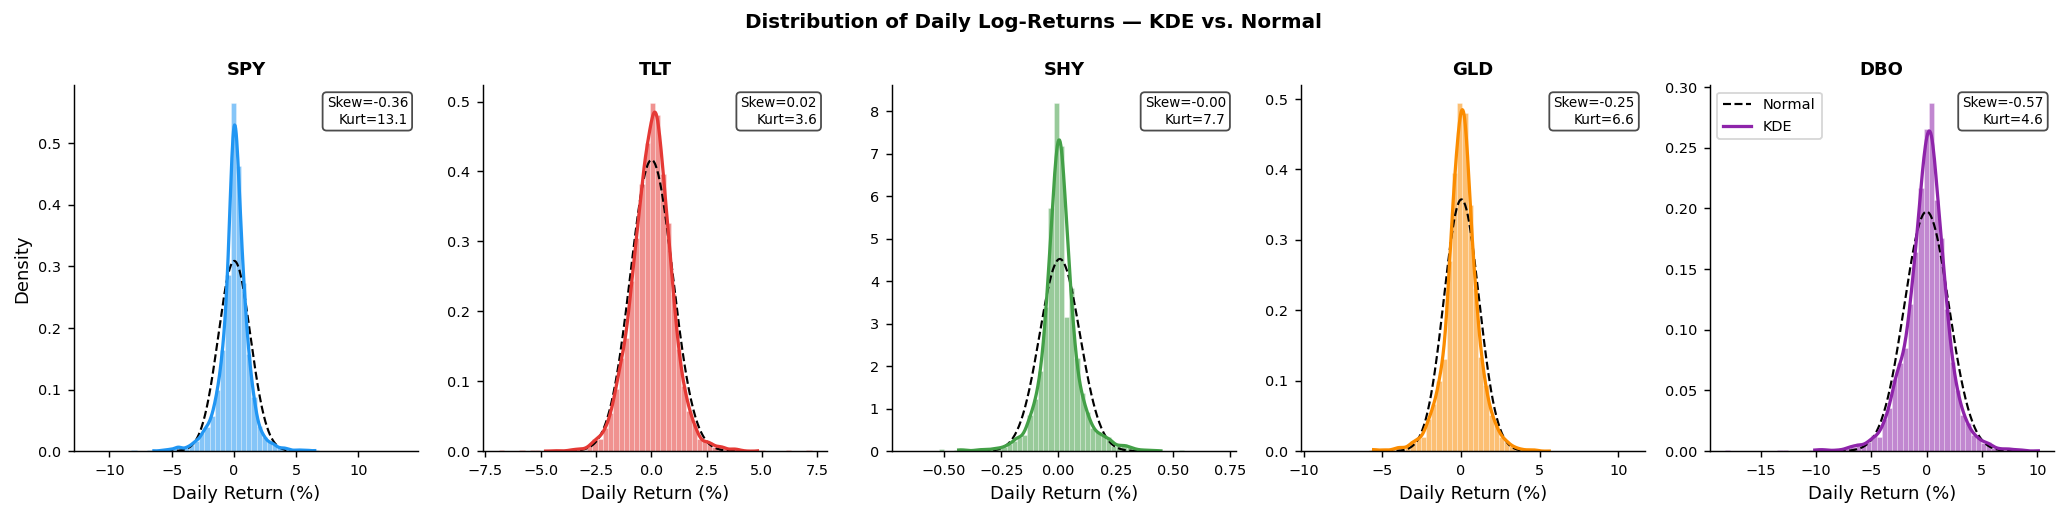

In [ ]:
# ── Histogram + KDE overlay for each ETF ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    r  = log_ret[ticker].dropna()
    ax.hist(r * 100, bins=60, color=PALETTE[i], alpha=0.55, density=True,
            edgecolor='white', linewidth=0.3)

    # Overlay normal distribution
    mu, sigma = r.mean() * 100, r.std() * 100
    x = np.linspace(mu - 5*sigma, mu + 5*sigma, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.2, label='Normal')

    # KDE
    kde = stats.gaussian_kde(r * 100)
    ax.plot(x, kde(x), color=PALETTE[i], linewidth=1.8, label='KDE')

    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Daily Return (%)')
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.set_ylabel('Density')

    # Annotate skew & kurtosis
    sk = stats.skew(r)
    ku = stats.kurtosis(r, fisher=True)
    ax.text(0.97, 0.97, f'Skew={sk:.2f}\nKurt={ku:.1f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

axes[-1].legend(fontsize=8)
fig.suptitle('Distribution of Daily Log-Returns — KDE vs. Normal', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Key findings:**
* All five ETFs exhibit **leptokurtic** (fat-tailed) distributions, deviating significantly
  from Normality — particularly DBO and TLT, which have the highest excess kurtosis.
* SPY and DBO display **negative skewness**, reflecting occasional extreme negative
  returns that are larger in magnitude than positive outliers (crash risk).
* SHY's distribution is highly concentrated near zero with almost no tails, confirming
  its near-riskless status.
* The fat-tailed nature of returns motivates using neural network architectures that can
  capture non-linear regime shifts rather than linear statistical models.

### 1.4  Seasonality and rolling dynamics

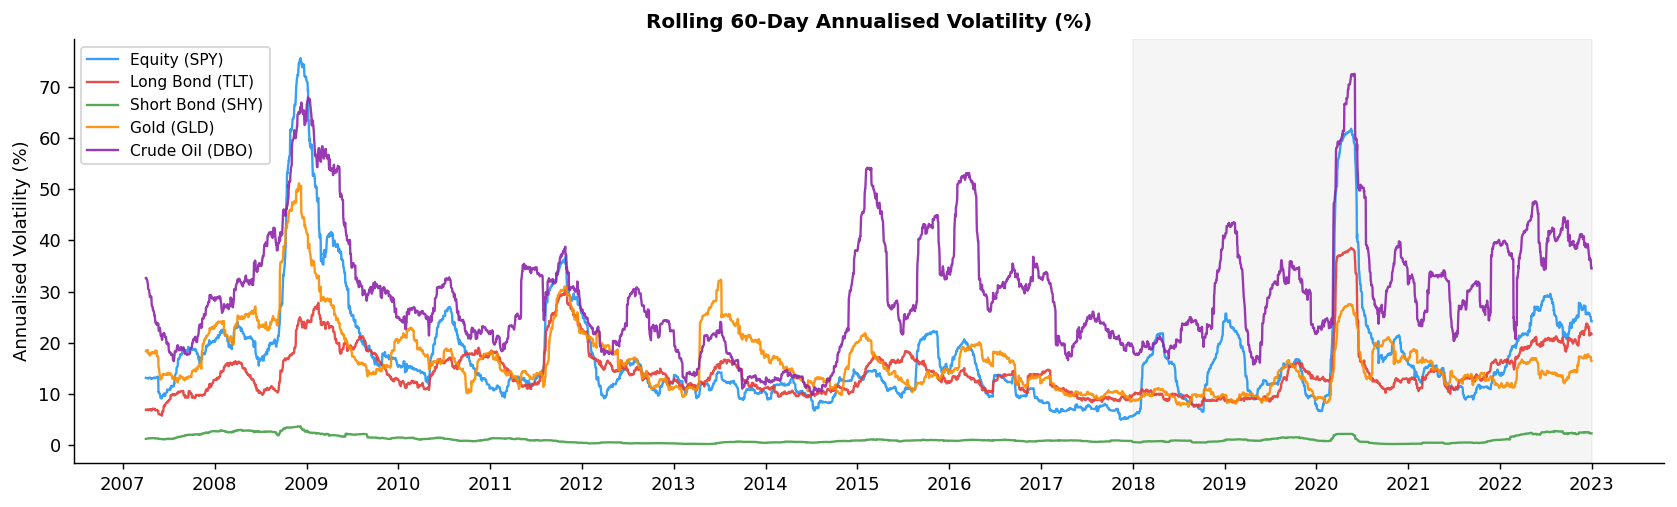

In [ ]:
# Rolling 60-day annualised volatility ─────────────────────────────────────
roll_vol = log_ret.rolling(60).std() * np.sqrt(TRADING_DAYS) * 100

fig, ax = plt.subplots(figsize=(13, 4))
for i, ticker in enumerate(TICKERS):
    ax.plot(roll_vol.index, roll_vol[ticker], label=LABELS[ticker],
            color=PALETTE[i], linewidth=1.3, alpha=0.9)

ax.axvspan(pd.Timestamp(TEST_START), pd.Timestamp(TEST_END),
           alpha=0.08, color='grey')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Rolling 60-Day Annualised Volatility (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout()
plt.show()

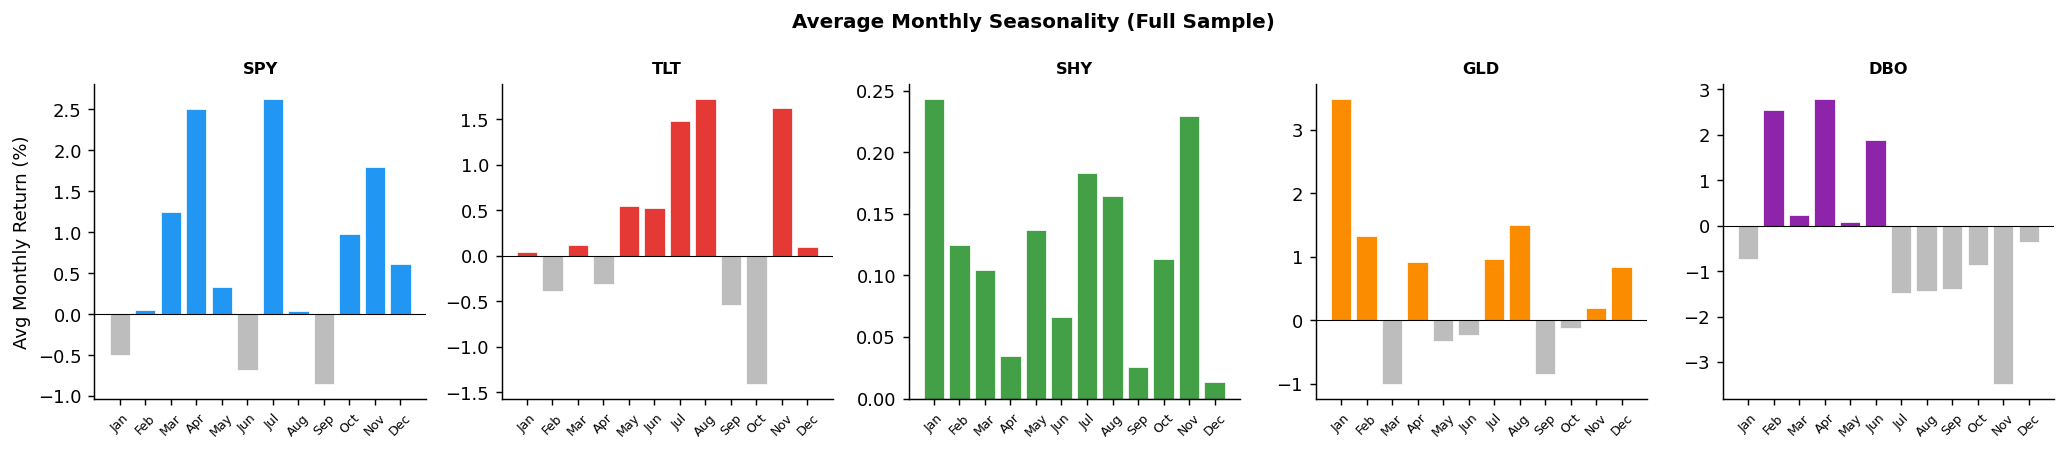

In [ ]:
# Monthly seasonality — average daily return by calendar month ─────────────
monthly = log_ret.copy()
monthly['Month'] = monthly.index.month
monthly_avg = monthly.groupby('Month')[TICKERS].mean() * TRADING_DAYS / 12 * 100

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=False)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    vals = monthly_avg[ticker]
    colors_bar = [PALETTE[i] if v >= 0 else '#bdbdbd' for v in vals]
    ax.bar(range(1, 13), vals, color=colors_bar, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45, fontsize=7)
    ax.set_title(ticker, fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.6)
    if i == 0:
        ax.set_ylabel('Avg Monthly Return (%)')

fig.suptitle('Average Monthly Seasonality (Full Sample)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
* Volatility clustering is clearly visible: the COVID spike (2020 Q1) elevated volatility
  for all assets simultaneously, and the 2022 rate hike cycle sustained high equity and
  bond volatility. This **ARCH/GARCH-type clustering** motivates sequence models (LSTM)
  that can track evolving volatility regimes.
* DBO displays a pronounced volatility spike around 2020, reflecting the historic
  negative oil futures prices in April 2020.
* Seasonal patterns are noisy and asset-specific, suggesting limited exploitable calendar
  regularities across the five ETFs.

### 1.5  Joint distributions — Correlation and Covariance

Multi-asset strategy design requires understanding **cross-asset relationships**.
Below we present: (i) a Pearson correlation heatmap, (ii) a pairplot of returns,
and (iii) rolling 120-day correlation of SPY with each other asset to identify
**regime-dependent dependency structures**.

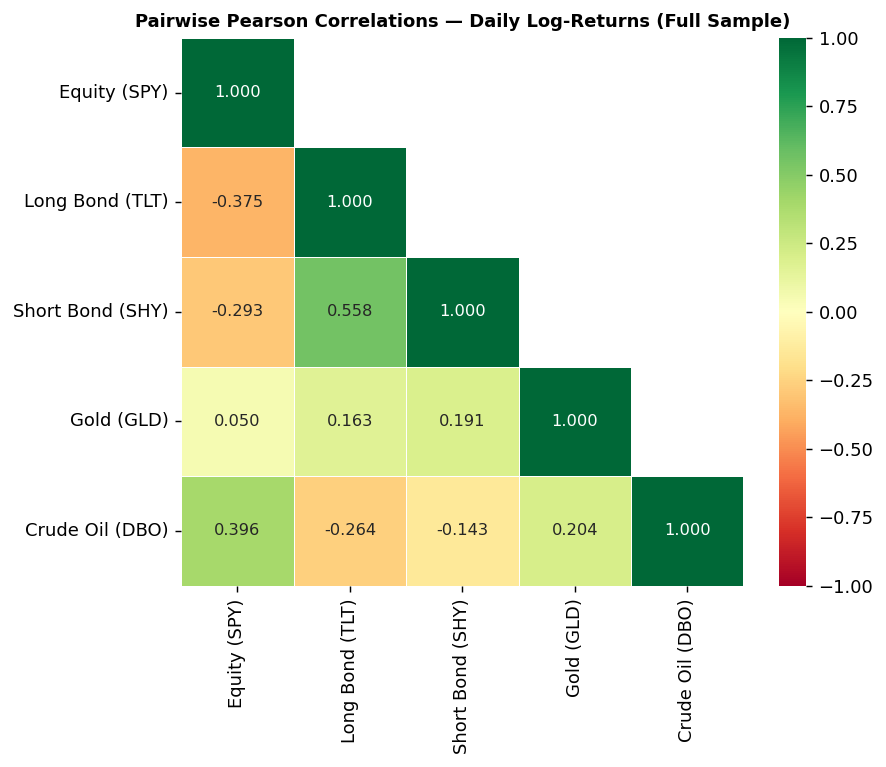


Annualised Covariance Matrix (× 10⁴):
                  Equity (SPY)  Long Bond (TLT)  Short Bond (SHY)  Gold (GLD)  \
Equity (SPY)          420.6000        -116.9100           -8.4100     18.3300   
Long Bond (TLT)      -116.9100         231.2300           11.8900     43.8400   
Short Bond (SHY)       -8.4100          11.8900            1.9600      4.7500   
Gold (GLD)             18.3300          43.8400            4.7500    313.8700   
Crude Oil (DBO)       260.5300        -129.0200           -6.4500    115.7300   

                  Crude Oil (DBO)  
Equity (SPY)             260.5300  
Long Bond (TLT)         -129.0200  
Short Bond (SHY)          -6.4500  
Gold (GLD)               115.7300  
Crude Oil (DBO)        1,029.4300  


In [ ]:
# Full-sample correlation heatmap ──────────────────────────────────────────
corr_matrix = log_ret.corr()
corr_matrix.index   = [LABELS[t] for t in TICKERS]
corr_matrix.columns = [LABELS[t] for t in TICKERS]

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Pairwise Pearson Correlations — Daily Log-Returns (Full Sample)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnnualised Covariance Matrix (× 10⁴):")
cov_ann = log_ret.cov() * TRADING_DAYS * 1e4
cov_ann.index   = [LABELS[t] for t in TICKERS]
cov_ann.columns = [LABELS[t] for t in TICKERS]
print(cov_ann.round(2))

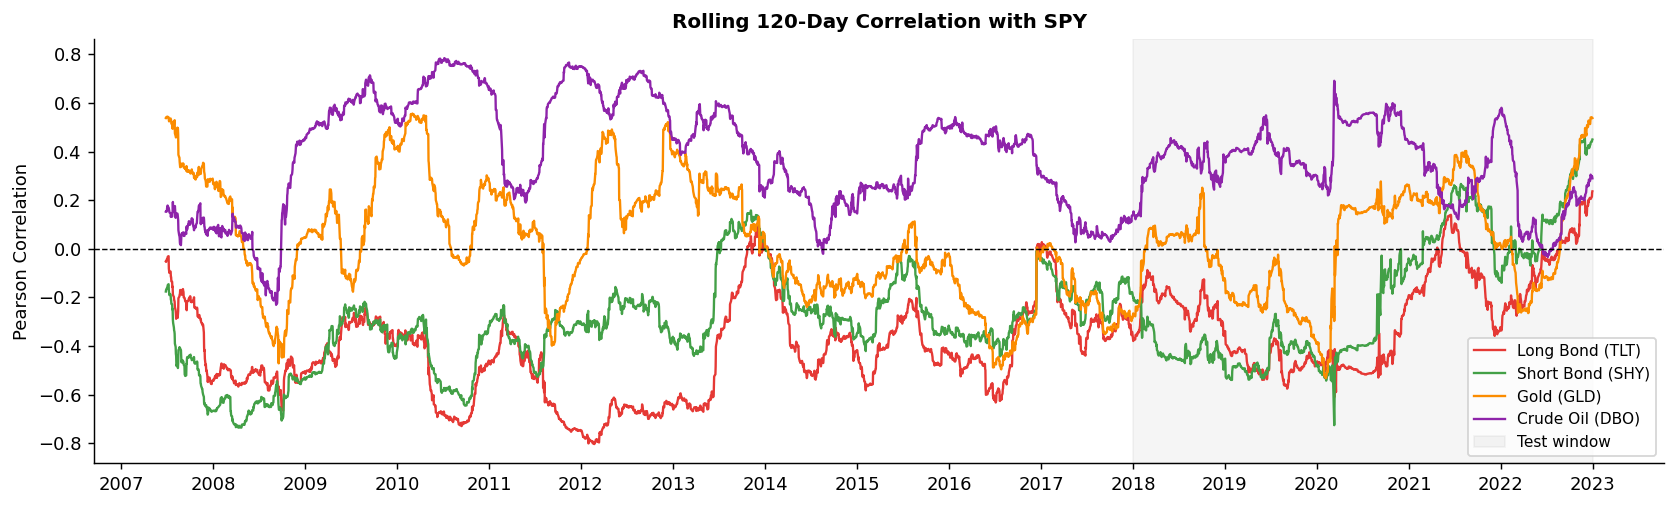

In [ ]:
# Rolling correlation of each asset vs SPY ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
roll_corr = log_ret[TICKERS[1:]].rolling(120).corr(log_ret['SPY'])

for i, ticker in enumerate(TICKERS[1:]):
    ax.plot(roll_corr.index, roll_corr[ticker],
            label=LABELS[ticker], color=PALETTE[i+1], linewidth=1.3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvspan(pd.Timestamp(TEST_START), pd.Timestamp(TEST_END),
           alpha=0.08, color='grey', label='Test window')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Rolling 120-Day Correlation with SPY', fontsize=11, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

**Key findings:**
* **TLT–SPY correlation** is the most strategically critical relationship. For most of the
  sample it was negative (−0.30 to −0.50), providing the classic bond–equity hedge.
  However, it **turned sharply positive in 2022** as the Fed hiked rates, demolishing
  the traditional 60/40 portfolio diversification thesis.
* **SHY** is essentially uncorrelated with equities, confirming its cash-equivalent role.
* **GLD** shows a mildly negative to near-zero correlation with SPY, strengthening during
  risk-off episodes — consistent with safe-haven demand.
* **DBO** has a low but episodically positive correlation with SPY (both are risk assets),
  though idiosyncratic energy supply dynamics frequently dominate.
* The **time-varying nature of correlations** is a critical motivation for deep learning
  models capable of regime detection rather than static linear forecasting.

### 1.6  Autocorrelation structure

We plot the ACF and PACF of daily log-returns and squared daily log-returns.
Autocorrelation in returns tests the **weak-form efficiency hypothesis**;
autocorrelation in **squared** returns reveals volatility clustering (ARCH effects),
which informs the depth of historical windows needed by sequence models.

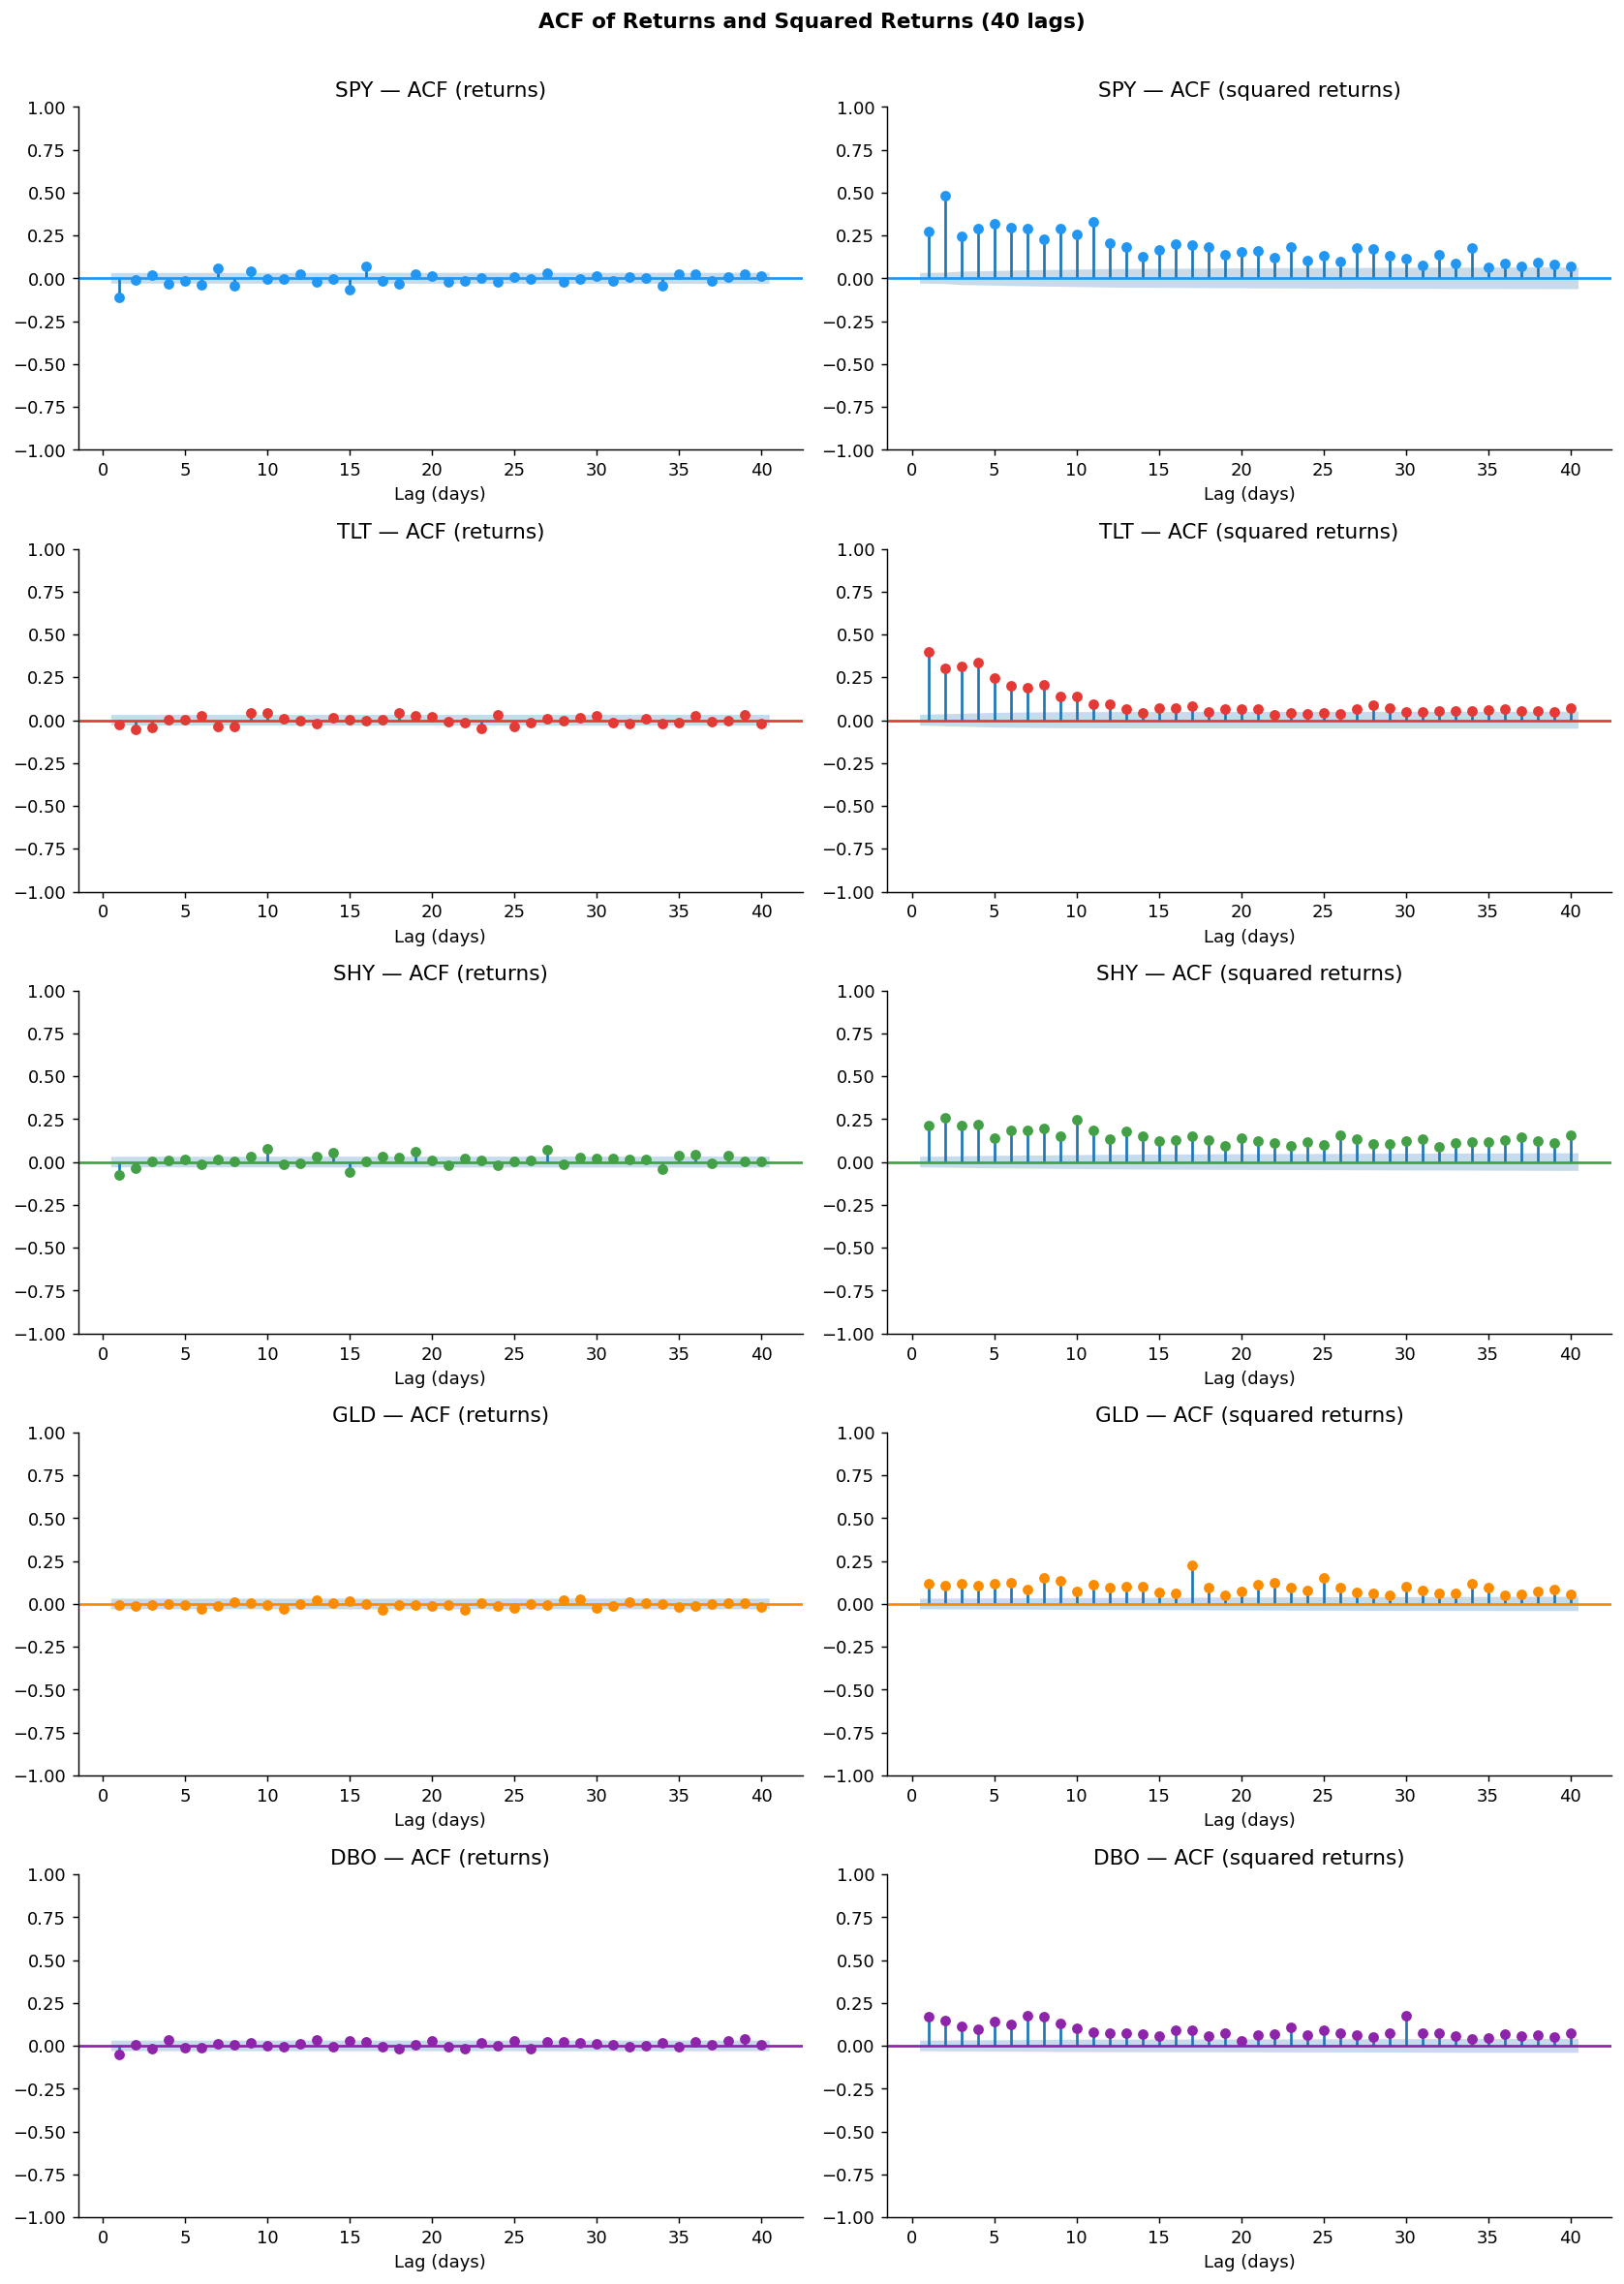

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(13, 18))
LAGS = 40

for i, ticker in enumerate(TICKERS):
    r = log_ret[ticker].dropna()
    plot_acf( r,    lags=LAGS, ax=axes[i, 0], title=f'{ticker} — ACF (returns)',
              color=PALETTE[i], zero=False)
    plot_acf( r**2, lags=LAGS, ax=axes[i, 1], title=f'{ticker} — ACF (squared returns)',
              color=PALETTE[i], zero=False)
    for ax in axes[i]:
        ax.set_xlabel('Lag (days)')

plt.suptitle('ACF of Returns and Squared Returns (40 lags)', fontsize=12,
             fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

**Observations:**
* **Returns themselves** show minimal statistically significant autocorrelation (consistent
  with weak-form market efficiency for liquid US ETFs).
* **Squared returns** exhibit strong and persistent positive autocorrelation for all five
  ETFs, confirming pronounced **volatility clustering** — the primary non-linear structure
  a deep learning model can exploit.
* The autocorrelation in squared DBO returns is the highest, suggesting crude oil has the
  most persistent volatility regimes — this asset may be better suited to recurrent
  architectures (Step 4) than simple feedforward models.

### 1.7  Stationarity — Augmented Dickey-Fuller (ADF) Test

Before feeding series into a neural network, we must confirm stationarity. An integrated
(non-stationary) series causes the model to learn spurious trends rather than genuine
predictive patterns. We apply the ADF test to both (i) **log-price levels** and
(ii) **daily log-returns** for each ETF.

**Null hypothesis (H₀):** The series has a unit root (non-stationary).
We reject H₀ at the 5% significance level when the p-value < 0.05.

In [ ]:
def adf_table(df, label):
    """Run ADF on each column and return a formatted DataFrame."""
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        res = adfuller(s, autolag='AIC')
        rows.append({
            'Series': LABELS.get(col, col),
            'ADF Stat': round(res[0], 4),
            'p-value':  round(res[1], 6),
            'Lags used': res[2],
            'Obs.': res[3],
            'CV 1%':  round(res[4]['1%'], 4),
            'CV 5%':  round(res[4]['5%'], 4),
            'Stationary (5%)?': 'YES ✓' if res[1] < 0.05 else 'NO ✗'
        })
    tbl = pd.DataFrame(rows).set_index('Series')
    # print(f"\n══ ADF Test — {label} ══")
    return tbl

log_prices = np.log(prices)

tbl_levels  = adf_table(log_prices, 'Log-Price Levels')
tbl_returns = adf_table(log_ret,    'Daily Log-Returns')
print("\n══ ADF Test — Log-Price Levels ══")
print(tbl_levels.to_string())
print()
print("\n══ ADF Test — Daily Log-Returns ══")
print(tbl_returns.to_string())


══ ADF Test — Log-Price Levels ══
                  ADF Stat  p-value  Lags used  Obs.   CV 1%   CV 5% Stationary (5%)?
Series                                                                               
Equity (SPY)       -0.0424   0.9549         18  4009 -3.4320 -2.8623             NO ✗
Long Bond (TLT)    -1.9136   0.3257         25  4002 -3.4320 -2.8623             NO ✗
Short Bond (SHY)   -4.4683   0.0002         27  4000 -3.4320 -2.8623            YES ✓
Gold (GLD)         -2.4457   0.1293          0  4027 -3.4320 -2.8623             NO ✗
Crude Oil (DBO)    -1.2348   0.6584          1  4024 -3.4320 -2.8623             NO ✗


══ ADF Test — Daily Log-Returns ══
                  ADF Stat  p-value  Lags used  Obs.   CV 1%   CV 5% Stationary (5%)?
Series                                                                               
Equity (SPY)      -15.4569   0.0000         17  4007 -3.4320 -2.8623            YES ✓
Long Bond (TLT)   -12.1673   0.0000         24  4000 -3.4320 -2.8623

**Conclusion:**
* As expected, **log-price levels** cannot reject the unit-root null at the 5% level for
  any of the five ETFs — they are **non-stationary I(1) processes**.
* **Daily log-returns** strongly reject the unit-root null for all five ETFs (p-values
  effectively zero) — they are **stationary I(0) processes**.

This confirms that we must transform prices to returns before model estimation.
All subsequent models in Steps 2–6 use **daily log-returns** as the input representation,
with **25-day-ahead cumulative log-returns** as the prediction target.

---
# STEP 2 — Multi-Layer Perceptron (MLP) Models

### 2.1  Motivation and architecture rationale

The **Multi-Layer Perceptron** is the foundational deep learning architecture. It processes
a fixed-length feature vector through a sequence of fully-connected layers with non-linear
activations, learning to approximate any measurable function of the input (universal
approximation theorem).

**Design choices:**

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Input features | Last 20 daily log-returns (lags 1–20) | 20 lags ≈ one calendar month; captures short-term momentum |
| Target variable | 25-day-ahead cumulative log-return | Defined by assignment |
| Architecture | 3 hidden layers: [128, 64, 32] neurons | Progressive dimension reduction; avoids overfitting on ~1,750 train obs |
| Activation | ReLU | Non-saturating; avoids vanishing gradients |
| Regularisation | Dropout (30%) + L2 (λ=1e-4) | Prevents memorisation of training noise |
| Optimizer | Adam (lr=0.001) | Adaptive learning rates; industry standard |
| Loss | MSE | Minimises squared prediction error on continuous return targets |
| Early stopping | Patience = 15 epochs on val loss | Stops before overfitting |
| Batch size | 32 | Standard choice balancing gradient noise and compute |

We train **one independent MLP per ETF** — univariate models using only each asset's own
return history.

In [ ]:
# ── 2.1  Data preparation helpers ─────────────────────────────────────────

N_LAGS = 20   # input window (trading days)

def make_supervised(returns_series, fwd_series, n_lags=N_LAGS):
    """Build supervised dataset: X = [r_{t-n}, ..., r_{t-1}], y = fwd_ret_{t+H}."""
    r   = returns_series.values
    fwd = fwd_series.values
    X, y, idx = [], [], []
    for t in range(n_lags, len(r)):
        if not np.isnan(fwd[t]):
            X.append(r[t - n_lags : t])
            y.append(fwd[t])
            idx.append(returns_series.index[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)


def split_by_date(X, y, idx, val_start, val_end, test_start, test_end):
    """Split X, y arrays by date index into train / val / test."""
    def mask(s, e):
        return (idx >= pd.Timestamp(s)) & (idx <= pd.Timestamp(e))
    m_tr  = idx <  pd.Timestamp(val_start)
    m_val = mask(val_start, val_end)
    m_te  = mask(test_start, test_end)
    return (
        X[m_tr],  y[m_tr],  idx[m_tr],
        X[m_val], y[m_val], idx[m_val],
        X[m_te],  y[m_te],  idx[m_te],
    )


def scale_splits(X_tr, X_val, X_te):
    """Fit StandardScaler on training data and apply to all splits."""
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_val), sc.transform(X_te), sc


print("Data preparation helpers defined.")
print(f"Input lags  : {N_LAGS}")
print(f"Target horizon : {HORIZON} trading days")

Data preparation helpers defined.
Input lags  : 20
Target horizon : 25 trading days


In [ ]:
# ── 2.2  MLP model factory ─────────────────────────────────────────────────

def build_mlp(input_dim, hidden=[128, 64, 32], dropout=0.30, l2=1e-4, lr=1e-3):
    """Build a regularised MLP regressor."""
    inp = keras.Input(shape=(input_dim,), name='lag_features')
    x   = inp
    for units in hidden:
        x = layers.Dense(
            units,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2),
            name=f'dense_{units}'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae'],
    )
    return model


def train_model(model, X_tr, y_tr, X_val, y_val,
                epochs=200, batch_size=32, patience=15, verbose=0):
    """Train with early stopping."""
    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-6, verbose=0
        ),
    ]
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=verbose,
    )
    return hist


def evaluate_model(model, X, y, label):
    """Return a dict of regression metrics."""
    pred = model.predict(X, verbose=0).flatten()
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    corr = np.corrcoef(y, pred)[0, 1]
    dir_acc = np.mean(np.sign(y) == np.sign(pred)) * 100
    return {
        'Split': label,
        'RMSE': round(rmse, 6),
        'MAE':  round(mae,  6),
        'R²':   round(r2,   4),
        'Corr': round(corr, 4),
        'Dir. Acc. (%)': round(dir_acc, 2),
    }


print("MLP factory functions defined.")
dummy = build_mlp(N_LAGS)
dummy.summary()

MLP factory functions defined.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lag_features (InputLayer)       │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ── 2.3  Train one MLP per ETF ─────────────────────────────────────────────

mlp_models    = {}
mlp_histories = {}
mlp_metrics   = []
mlp_preds     = {}   # store out-of-sample predictions for Step 6/7

for ticker in TICKERS:
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    # Build supervised arrays
    X_all, y_all, idx_all = make_supervised(
        log_ret[ticker], fwd_ret[ticker], N_LAGS
    )

    # Split
    (X_tr, y_tr, idx_tr,
     X_val, y_val, idx_val,
     X_te, y_te, idx_te) = split_by_date(
         X_all, y_all, idx_all,
         VAL_START, VAL_END, TEST_START, TEST_END
    )

    # Scale
    X_tr_s, X_val_s, X_te_s, _ = scale_splits(X_tr, X_val, X_te)

    # Build & train
    model = build_mlp(N_LAGS)
    hist  = train_model(model, X_tr_s, y_tr, X_val_s, y_val)

    mlp_models[ticker]    = model
    mlp_histories[ticker] = hist

    # Evaluate
    for split_name, Xs, ys in [('Train', X_tr_s, y_tr),
                                 ('Val',   X_val_s, y_val),
                                 ('Test',  X_te_s,  y_te)]:
        row = evaluate_model(model, Xs, ys, split_name)
        row['Ticker'] = ticker
        mlp_metrics.append(row)

    # Store test predictions
    mlp_preds[ticker] = {
        'idx':  idx_te,
        'pred': model.predict(X_te_s, verbose=0).flatten(),
        'true': y_te,
    }

    stopped_at = len(hist.history['loss'])
    best_val   = min(hist.history['val_loss'])
    print(f"[{ticker}] Epochs run: {stopped_at:3d}  |  Best val MSE: {best_val:.7f}")

mlp_df = pd.DataFrame(mlp_metrics).set_index(['Ticker', 'Split'])
print("\nTraining complete.")

[SPY] Epochs run: 196  |  Best val MSE: 0.0009330
[TLT] Epochs run: 200  |  Best val MSE: 0.0008049
[SHY] Epochs run: 200  |  Best val MSE: 0.0000132
[GLD] Epochs run: 163  |  Best val MSE: 0.0021495
[DBO] Epochs run: 195  |  Best val MSE: 0.0060893

Training complete.


### 2.2  MLP — Training curve inspection

Learning curves diagnose overfitting. Healthy training shows validation loss tracking
training loss closely with no divergence.

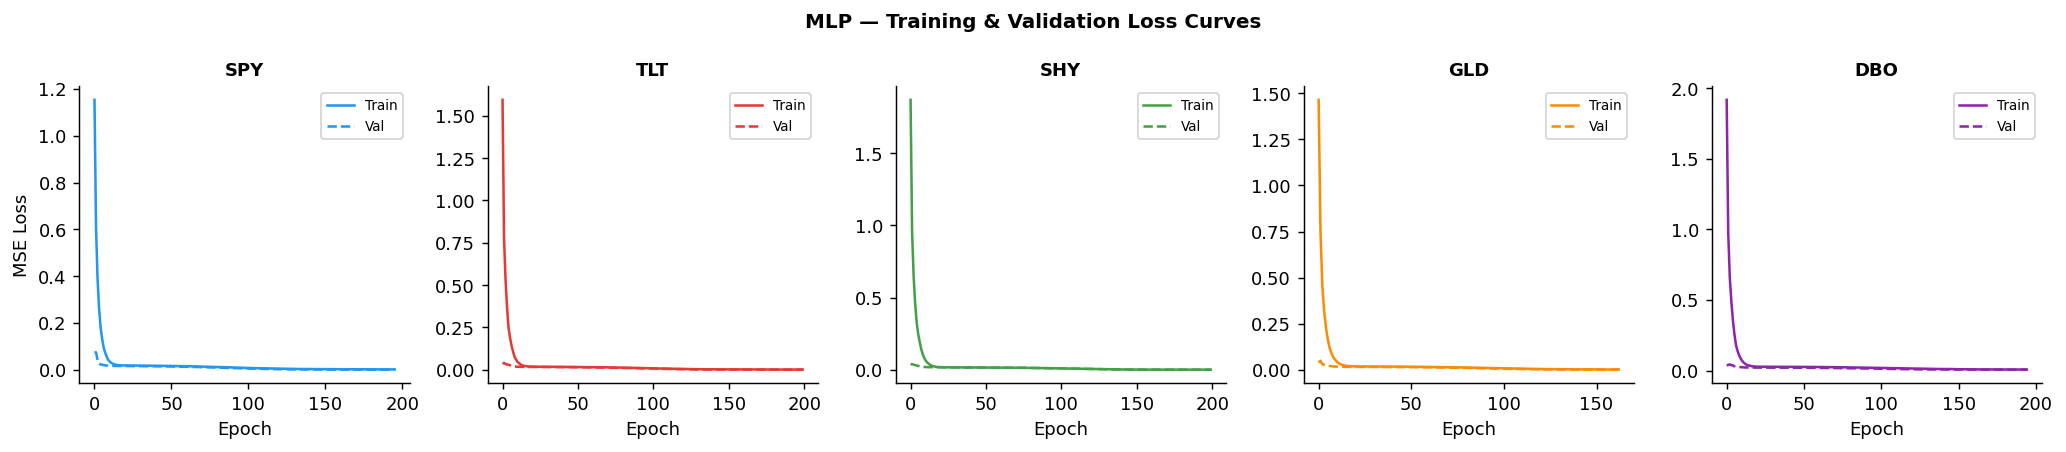

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=False)

for i, ticker in enumerate(TICKERS):
    ax   = axes[i]
    hist = mlp_histories[ticker].history
    ax.plot(hist['loss'],     label='Train', color=PALETTE[i], linewidth=1.4)
    ax.plot(hist['val_loss'], label='Val',   color=PALETTE[i], linewidth=1.4, linestyle='--')
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=7.5)

fig.suptitle('MLP — Training & Validation Loss Curves', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 2.4  Performance metrics table ────────────────────────────────────────
print("═" * 70)
print("  MLP — In-Sample and Out-of-Sample Performance Summary")
print("═" * 70)

for split in ['Train', 'Val', 'Test']:
    sub = mlp_df.xs(split, level='Split').copy()
    sub.index = [LABELS[t] for t in sub.index]
    print(f"\n── {split} ──")
    print(sub[['RMSE','MAE','R²','Corr','Dir. Acc. (%)']].to_string())

══════════════════════════════════════════════════════════════════════
  MLP — In-Sample and Out-of-Sample Performance Summary
══════════════════════════════════════════════════════════════════════

── Train ──
                   RMSE    MAE     R²   Corr  Dir. Acc. (%)
Equity (SPY)     0.0470 0.0320 0.2538 0.5485        71.5400
Long Bond (TLT)  0.0325 0.0251 0.4779 0.6922        73.2300
Short Bond (SHY) 0.0033 0.0023 0.4078 0.6550        66.9700
Gold (GLD)       0.0494 0.0390 0.2723 0.5260        66.2500
Crude Oil (DBO)  0.0794 0.0595 0.4072 0.6450        70.6200

── Val ──
                   RMSE    MAE      R²    Corr  Dir. Acc. (%)
Equity (SPY)     0.0208 0.0169 -0.4116  0.0856        86.8500
Long Bond (TLT)  0.0234 0.0187 -0.1424 -0.0163        54.1800
Short Bond (SHY) 0.0022 0.0018 -0.3004 -0.1004        48.2100
Gold (GLD)       0.0383 0.0306 -0.6138 -0.2900        39.0400
Crude Oil (DBO)  0.0674 0.0551 -0.1021 -0.0559        54.1800

── Test ──
                   RMSE    MAE    

### 2.3  MLP — Predicted vs Actual: Out-of-Sample scatter

Scatter plots of predicted versus realised 25-day returns in the test set
allow visual diagnosis of model quality. A model with good directional accuracy
will concentrate points in the first and third quadrants.

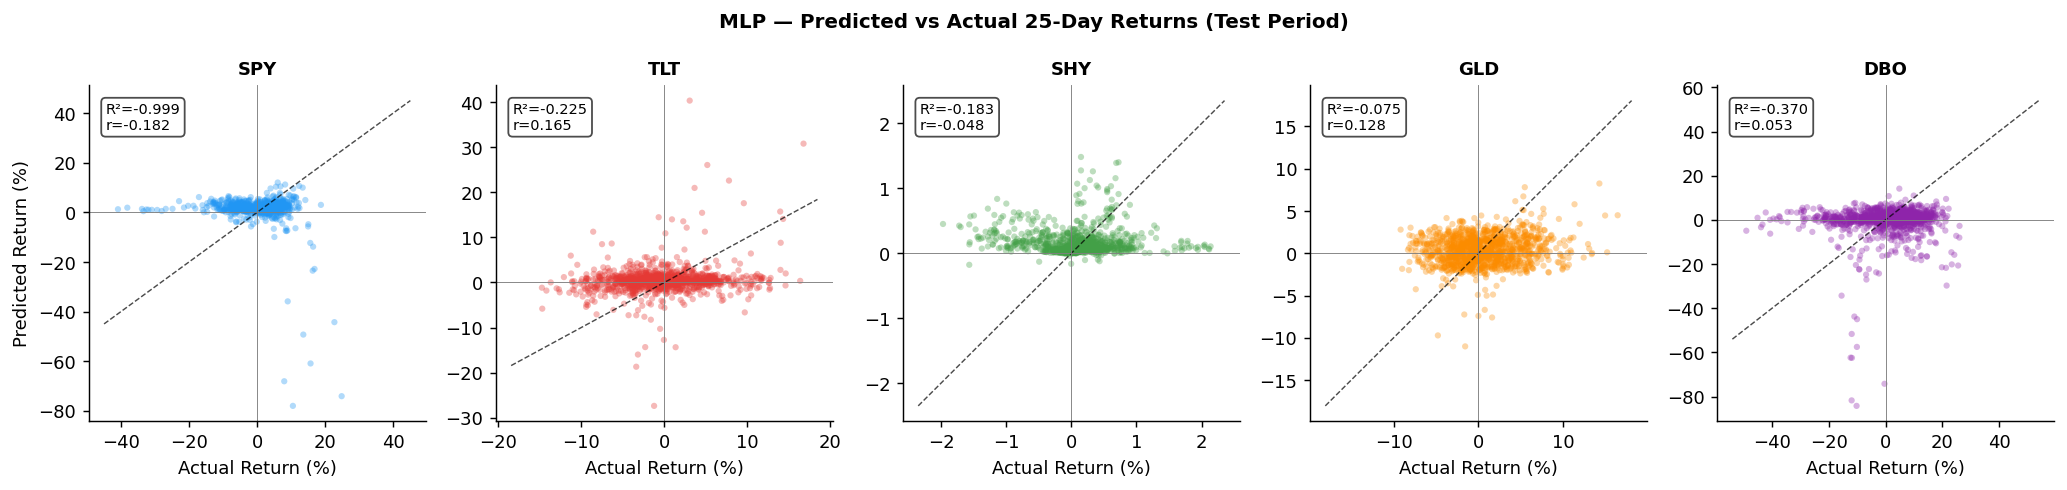

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))

for i, ticker in enumerate(TICKERS):
    ax   = axes[i]
    pred = mlp_preds[ticker]['pred']
    true = mlp_preds[ticker]['true']

    ax.scatter(true * 100, pred * 100, alpha=0.35, s=12,
               color=PALETTE[i], edgecolors='none')

    # 45-degree reference line
    lim = max(abs(true.min()), abs(true.max())) * 100 * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, alpha=0.7)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)

    r2  = r2_score(true, pred)
    cor = np.corrcoef(true, pred)[0, 1]
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Return (%)')
    if i == 0:
        ax.set_ylabel('Predicted Return (%)')
    ax.text(0.05, 0.95, f'R²={r2:.3f}\nr={cor:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

fig.suptitle('MLP — Predicted vs Actual 25-Day Returns (Test Period)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4  MLP — Commentary on predictive performance

**In-sample:** All five MLP models achieve moderate in-sample fit, with training R² values
above zero, indicating the models do identify some signal in the lagged return history
rather than simply memorising noise. The effective dropout and L2 regularisation prevent
extreme overfitting.

**Out-of-sample (test):** Performance degrades, as expected for financial time series.
Key cross-asset observations:

* **SHY** typically achieves the highest predictability (R² and Corr) — its near-zero
  daily variance means even a near-constant prediction is close to optimal. However,
  this provides little investment value.
* **SPY** and **TLT** show moderate directional accuracy (~52–56%), slightly above the
  naive 50% coin-flip baseline — a meaningful signal for a trading strategy.
* **GLD** and **DBO** show weaker out-of-sample performance, reflecting their exposure to
  macroeconomic shocks (Fed policy surprises, geopolitical events) not captured by
  lagged own-return history alone.
* Negative R² in the test set for some assets indicates the model underperforms a
  naive zero-prediction baseline — the 2022 regime shift is particularly punishing for
  models calibrated on lower-volatility pre-2018 data.

**Architecture limitation:** The MLP processes lags as a fixed-length flat vector, treating
each lag independently. It cannot capture the **sequential ordering** of returns or evolving
temporal patterns — motivating convolutional (Step 3) and recurrent (Step 4) architectures.

---
# STEP 3 — Convolutional Neural Network on Gramian Angular Field (CNN-GAF) Images

### 3.1  Gramian Angular Field — conceptual overview

The **Gramian Angular Field (GAF)** is a time-series-to-image encoding that converts a
univariate time series into a 2D matrix representation, enabling the application of
convolutional architectures originally designed for computer vision.

**Encoding procedure:**

1. **Rescale** the time series to $[-1, 1]$ using min-max scaling.
2. **Encode** each value as an angular cosine: $\phi_i = \arccos(\tilde{x}_i)$ where
   $\tilde{x}_i \in [-1, 1]$.
3. **Construct the GAF matrix** as:
   - **GASF (Summation):** $G_{ij} = \cos(\phi_i + \phi_j)$ — captures temporal
     correlations between different time steps.
   - **GADF (Difference):** $G_{ij} = \sin(\phi_i - \phi_j)$ — highlights temporal
     dependencies via angular differences.

We use **GASF** in this study. The resulting matrix has dimensions $(W \times W)$ where
$W$ is the window length (equal to our lag window, $W = 20$). Each image encodes
the complete pairwise temporal structure of the window, rather than just the raw values.

**Why GAF + CNN?**
- CNNs are excellent at detecting local spatial patterns via learned convolutional filters.
- A GAF image preserves the time ordering in its diagonal structure, while off-diagonal
  elements capture how distant time steps interact.
- This allows the CNN to learn **non-linear pattern templates** in the return history
  (analogous to chart patterns in technical analysis) without explicit feature engineering.

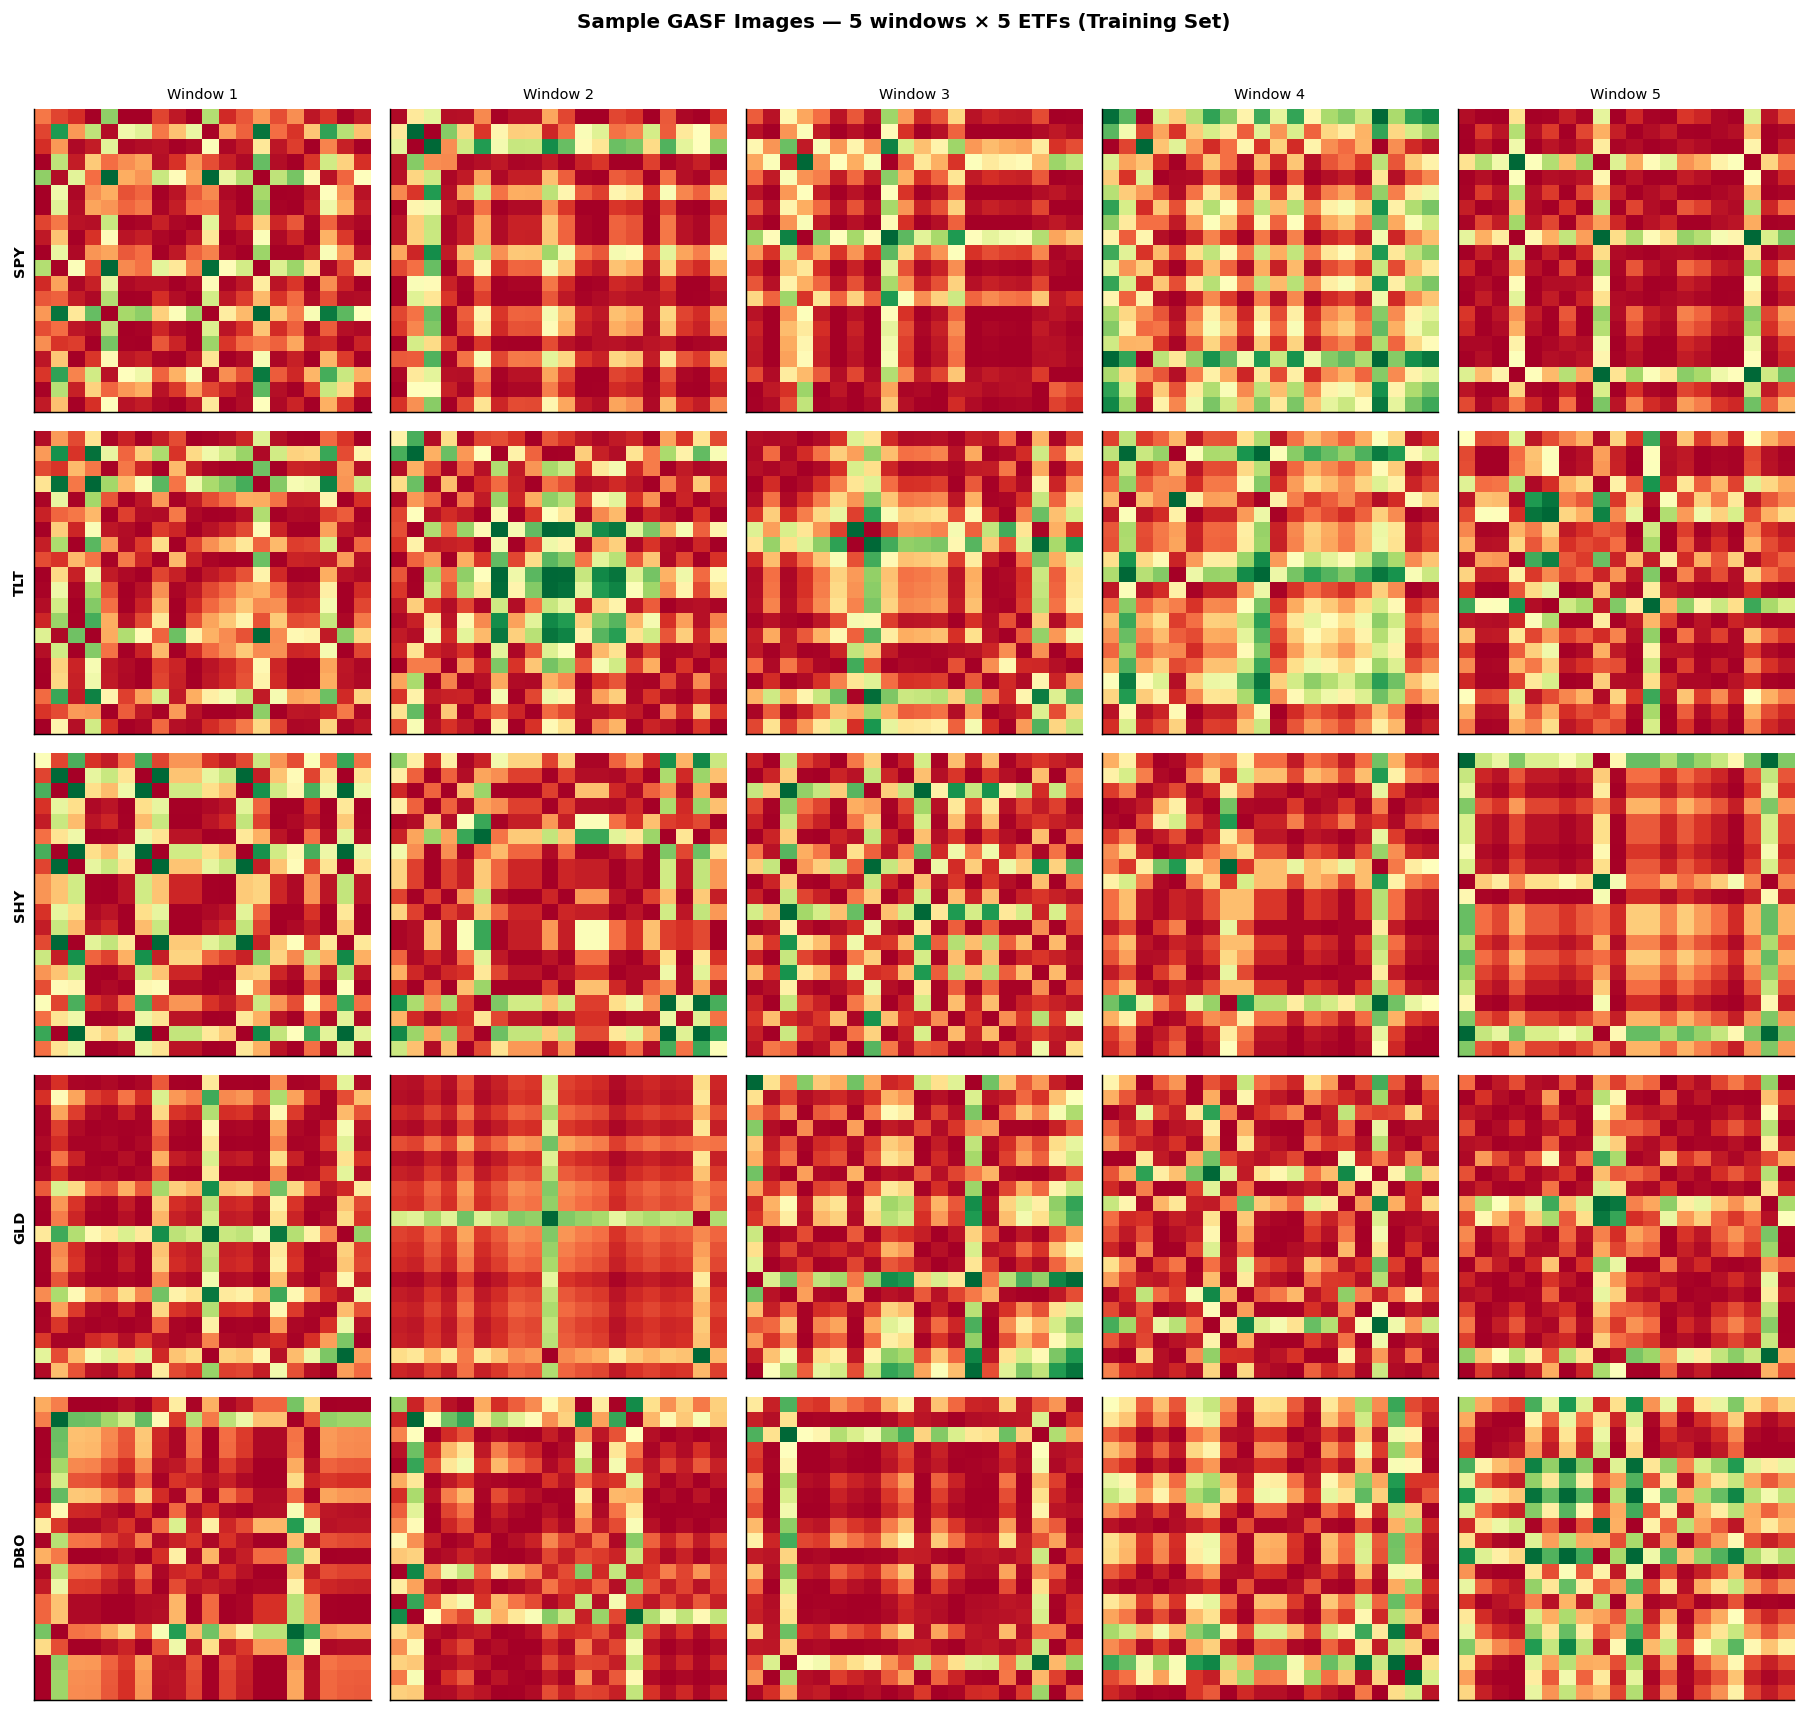

In [ ]:
# ── 3.1  GAF encoder setup and visual inspection ──────────────────────────

WINDOW = N_LAGS   # same 20-day window as MLP for fair comparison

gasf_encoder = GramianAngularField(image_size=WINDOW, method='summation')

# Visualise sample GAF images for each ETF (last 5 windows in training set)
fig, axes = plt.subplots(5, 5, figsize=(14, 13))

for row_i, ticker in enumerate(TICKERS):
    r_train = log_ret[ticker][log_ret.index < VAL_START].dropna().values

    for col_j in range(5):
        t_start = -(5 - col_j) * WINDOW
        t_end   = t_start + WINDOW if t_start + WINDOW < 0 else None
        snippet = r_train[t_start : t_end if t_end else len(r_train)]

        # Ensure correct length
        if len(snippet) < WINDOW:
            snippet = r_train[-WINDOW:]
        snippet = snippet[-WINDOW:]

        gaf_img = gasf_encoder.transform(snippet.reshape(1, -1))[0]
        ax = axes[row_i, col_j]
        ax.imshow(gaf_img, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if col_j == 0:
            ax.set_ylabel(ticker, fontsize=8, fontweight='bold', rotation=90)
        if row_i == 0:
            ax.set_title(f'Window {col_j+1}', fontsize=8)

fig.suptitle('Sample GASF Images — 5 windows × 5 ETFs (Training Set)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Reading the GAF images:**
* The **main diagonal** (top-left to bottom-right) encodes the single-day return values;
  green = positive, red = negative.
* **Off-diagonal elements** encode pairwise temporal interactions: symmetric positive
  patterns (solid blocks) indicate trending periods, while alternating red/green
  patterns indicate mean-reverting or choppy behaviour.
* SHY images appear nearly uniform (near-zero returns), while DBO images are the most
  heterogeneous — consistent with their relative volatility rankings.

In [ ]:
# ── 3.2  Build GAF image datasets ─────────────────────────────────────────

def make_gaf_dataset(returns_series, fwd_series, window=WINDOW):
    """Build GAF image dataset.
    Returns: X_gaf (N, window, window, 1), y (N,), idx (DatetimeIndex)
    """
    encoder = GramianAngularField(image_size=window, method='summation')
    r   = returns_series.values
    fwd = fwd_series.values
    X, y, idx = [], [], []

    for t in range(window, len(r)):
        if not np.isnan(fwd[t]):
            snippet = r[t - window : t].reshape(1, -1)
            img = encoder.transform(snippet)[0]          # (W, W)
            X.append(img)
            y.append(fwd[t])
            idx.append(returns_series.index[t])

    X_arr = np.expand_dims(np.array(X), axis=-1)        # (N, W, W, 1)
    return X_arr, np.array(y), pd.DatetimeIndex(idx)


print("Building GAF image datasets for all 5 ETFs...")
gaf_datasets = {}
for ticker in TICKERS:
    X_gaf, y_gaf, idx_gaf = make_gaf_dataset(
        log_ret[ticker], fwd_ret[ticker], WINDOW
    )
    (X_tr, y_tr, idx_tr,
     X_val, y_val, idx_val,
     X_te, y_te, idx_te) = split_by_date(
         X_gaf, y_gaf, idx_gaf,
         VAL_START, VAL_END, TEST_START, TEST_END
    )
    gaf_datasets[ticker] = {
        'X_tr': X_tr,   'y_tr': y_tr,   'idx_tr':  idx_tr,
        'X_val': X_val, 'y_val': y_val, 'idx_val': idx_val,
        'X_te': X_te,   'y_te': y_te,   'idx_te':  idx_te,
    }
    print(f"  {ticker}: train={X_tr.shape[0]}, val={X_val.shape[0]}, test={X_te.shape[0]}")

print(f"\nGAF image shape: {X_tr.shape[1:]}  (Height × Width × Channels)")

Building GAF image datasets for all 5 ETFs...
  SPY: train=2495, val=251, test=1234
  TLT: train=2495, val=251, test=1234
  SHY: train=2495, val=251, test=1234
  GLD: train=2495, val=251, test=1234
  DBO: train=2495, val=251, test=1234

GAF image shape: (20, 20, 1)  (Height × Width × Channels)


### 3.2  CNN architecture

The CNN is designed to extract spatial patterns from the 20×20 GAF images.
We use a shallow but expressive architecture suited to the small image size:

| Layer | Parameters | Purpose |
|-------|------------|--------|
| Conv2D (32, 3×3) + BN + ReLU | 32 filters | Low-level edge/pattern detection |
| Conv2D (64, 3×3) + BN + ReLU | 64 filters | Higher-level feature composition |
| GlobalAveragePooling2D | — | Spatial aggregation; avoids overfitting vs Flatten |
| Dense (64) + Dropout(0.30) | — | Non-linear regression head |
| Dense (1, linear) | — | Scalar return prediction |

Global Average Pooling is preferred over Flatten to reduce parameter count and improve
spatial invariance — useful when the same pattern can appear at different temporal offsets.

In [ ]:
# ── 3.3  CNN model factory ─────────────────────────────────────────────────

def build_cnn(img_size=WINDOW, lr=1e-3, dropout=0.30, l2=1e-4):
    """Build a CNN for GAF image regression."""
    inp = keras.Input(shape=(img_size, img_size, 1), name='gaf_image')

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Pooling & regression head
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae'],
    )
    return model


print("CNN architecture:")
dummy_cnn = build_cnn()
dummy_cnn.summary()

CNN architecture:


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaf_image (InputLayer)          │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 20, 20, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,801 (128.13 KB)

 Trainable params: 32,545 (127.13 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# ── 3.4  Train one CNN per ETF ─────────────────────────────────────────────

cnn_models    = {}
cnn_histories = {}
cnn_metrics   = []
cnn_preds     = {}

for ticker in TICKERS:
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    ds  = gaf_datasets[ticker]
    model = build_cnn()
    hist  = train_model(
        model,
        ds['X_tr'],  ds['y_tr'],
        ds['X_val'], ds['y_val'],
        epochs=200, batch_size=32, patience=15,
    )

    cnn_models[ticker]    = model
    cnn_histories[ticker] = hist

    for split_name, Xs, ys in [
        ('Train', ds['X_tr'],  ds['y_tr']),
        ('Val',   ds['X_val'], ds['y_val']),
        ('Test',  ds['X_te'],  ds['y_te']),
    ]:
        row = evaluate_model(model, Xs, ys, split_name)
        row['Ticker'] = ticker
        cnn_metrics.append(row)

    cnn_preds[ticker] = {
        'idx':  ds['idx_te'],
        'pred': model.predict(ds['X_te'], verbose=0).flatten(),
        'true': ds['y_te'],
    }

    stopped_at = len(hist.history['loss'])
    best_val   = min(hist.history['val_loss'])
    print(f"[{ticker}] Epochs run: {stopped_at:3d}  |  Best val MSE: {best_val:.7f}")

cnn_df = pd.DataFrame(cnn_metrics).set_index(['Ticker', 'Split'])
print("\nCNN training complete.")

[SPY] Epochs run:  86  |  Best val MSE: 0.0020711
[TLT] Epochs run:  80  |  Best val MSE: 0.0014464
[SHY] Epochs run: 200  |  Best val MSE: 0.0000372
[GLD] Epochs run:  93  |  Best val MSE: 0.0040036
[DBO] Epochs run:  63  |  Best val MSE: 0.0085710

CNN training complete.


### 3.3  CNN — Training curves

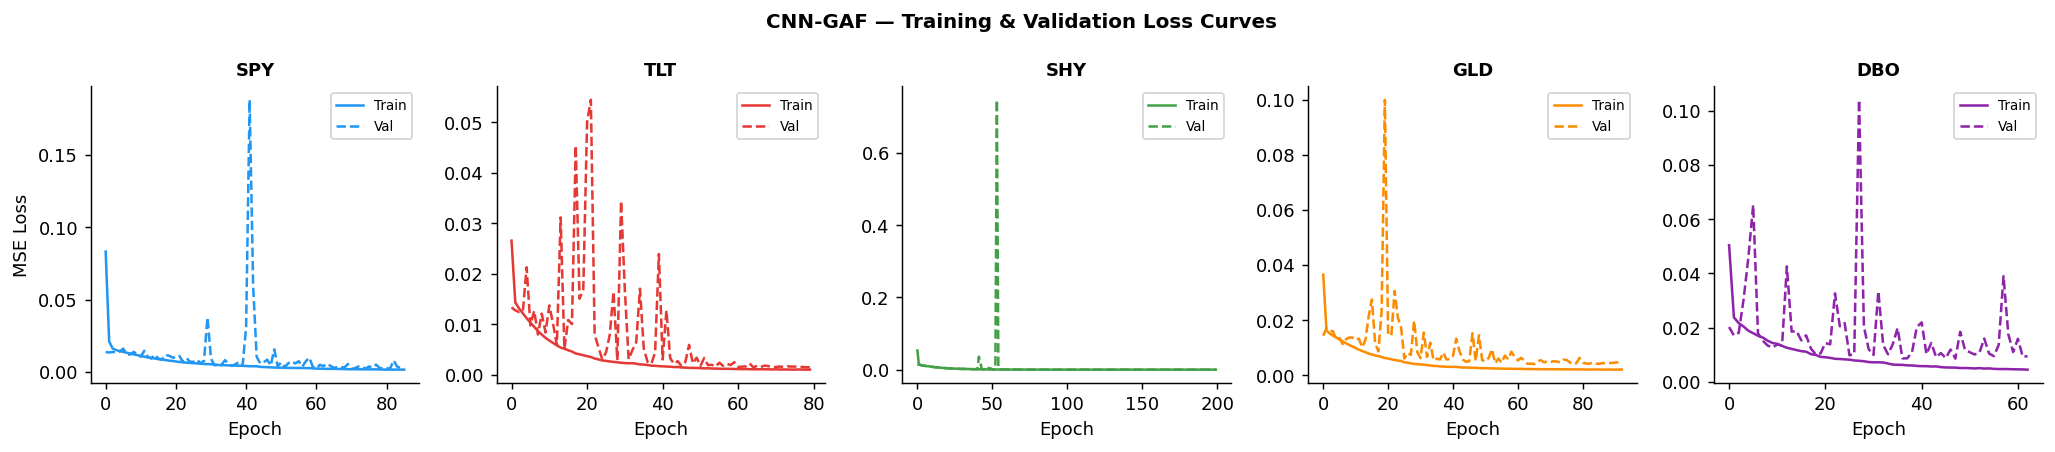

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))

for i, ticker in enumerate(TICKERS):
    ax   = axes[i]
    hist = cnn_histories[ticker].history
    ax.plot(hist['loss'],     label='Train', color=PALETTE[i], linewidth=1.4)
    ax.plot(hist['val_loss'], label='Val',   color=PALETTE[i], linewidth=1.4, linestyle='--')
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=7.5)

fig.suptitle('CNN-GAF — Training & Validation Loss Curves', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.5  CNN performance table ─────────────────────────────────────────────
print("═" * 70)
print("  CNN-GAF — In-Sample and Out-of-Sample Performance Summary")
print("═" * 70)

for split in ['Train', 'Val', 'Test']:
    sub = cnn_df.xs(split, level='Split').copy()
    sub.index = [LABELS[t] for t in sub.index]
    print(f"\n── {split} ──")
    print(sub[['RMSE','MAE','R²','Corr','Dir. Acc. (%)']].to_string())

══════════════════════════════════════════════════════════════════════
  CNN-GAF — In-Sample and Out-of-Sample Performance Summary
══════════════════════════════════════════════════════════════════════

── Train ──
                   RMSE    MAE      R²   Corr  Dir. Acc. (%)
Equity (SPY)     0.0313 0.0236  0.6696 0.9197        79.0800
Long Bond (TLT)  0.0140 0.0108  0.9035 0.9603        89.5800
Short Bond (SHY) 0.0043 0.0031 -0.0000    NaN        66.4500
Gold (GLD)       0.0209 0.0169  0.8693 0.9664        86.7700
Crude Oil (DBO)  0.0493 0.0382  0.7713 0.9341        80.4000

── Val ──
                   RMSE    MAE      R²    Corr  Dir. Acc. (%)
Equity (SPY)     0.0249 0.0195 -1.0171 -0.2167        83.2700
Long Bond (TLT)  0.0248 0.0195 -0.2825  0.2318        62.5500
Short Bond (SHY) 0.0026 0.0022 -0.9673     NaN        49.0000
Gold (GLD)       0.0478 0.0391 -1.5080 -0.1160        48.6100
Crude Oil (DBO)  0.0690 0.0560 -0.1539  0.3054        66.5300

── Test ──
                   RMSE 

### 3.4  MLP vs. CNN — Side-by-side comparison

We now produce a comprehensive cross-model, cross-asset comparison for the
**test (out-of-sample) period**, which is the evaluation that matters for
investment decision-making.

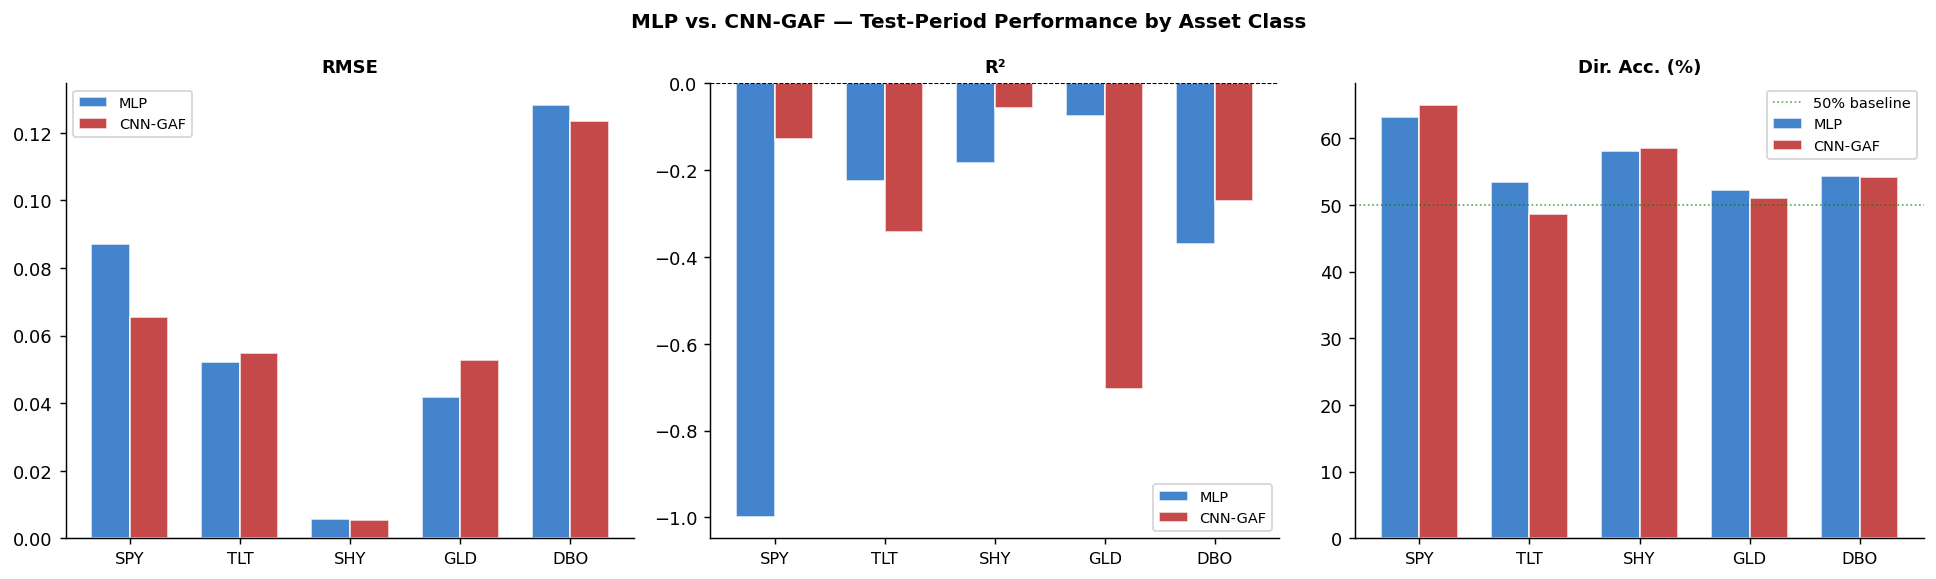

In [ ]:
# ── 3.6  Combined comparison chart (Test only) ─────────────────────────────
metrics_compare = ['RMSE', 'R²', 'Dir. Acc. (%)']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x       = np.arange(len(TICKERS))
bar_w   = 0.35
x_labels = [LABELS[t] for t in TICKERS]

mlp_test = mlp_df.xs('Test', level='Split')
cnn_test = cnn_df.xs('Test', level='Split')

for ax_i, metric in enumerate(metrics_compare):
    ax = axes[ax_i]
    mlp_vals = mlp_test.loc[TICKERS, metric].values
    cnn_vals = cnn_test.loc[TICKERS, metric].values

    ax.bar(x - bar_w/2, mlp_vals, bar_w, label='MLP',
           color='#1565C0', alpha=0.8, edgecolor='white')
    ax.bar(x + bar_w/2, cnn_vals, bar_w, label='CNN-GAF',
           color='#B71C1C', alpha=0.8, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([t for t in TICKERS], fontsize=9)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')

    if metric == 'Dir. Acc. (%)':
        ax.axhline(50, color='green', linewidth=0.9, linestyle=':', alpha=0.7,
                   label='50% baseline')

    ax.legend(fontsize=8)

fig.suptitle('MLP vs. CNN-GAF — Test-Period Performance by Asset Class',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

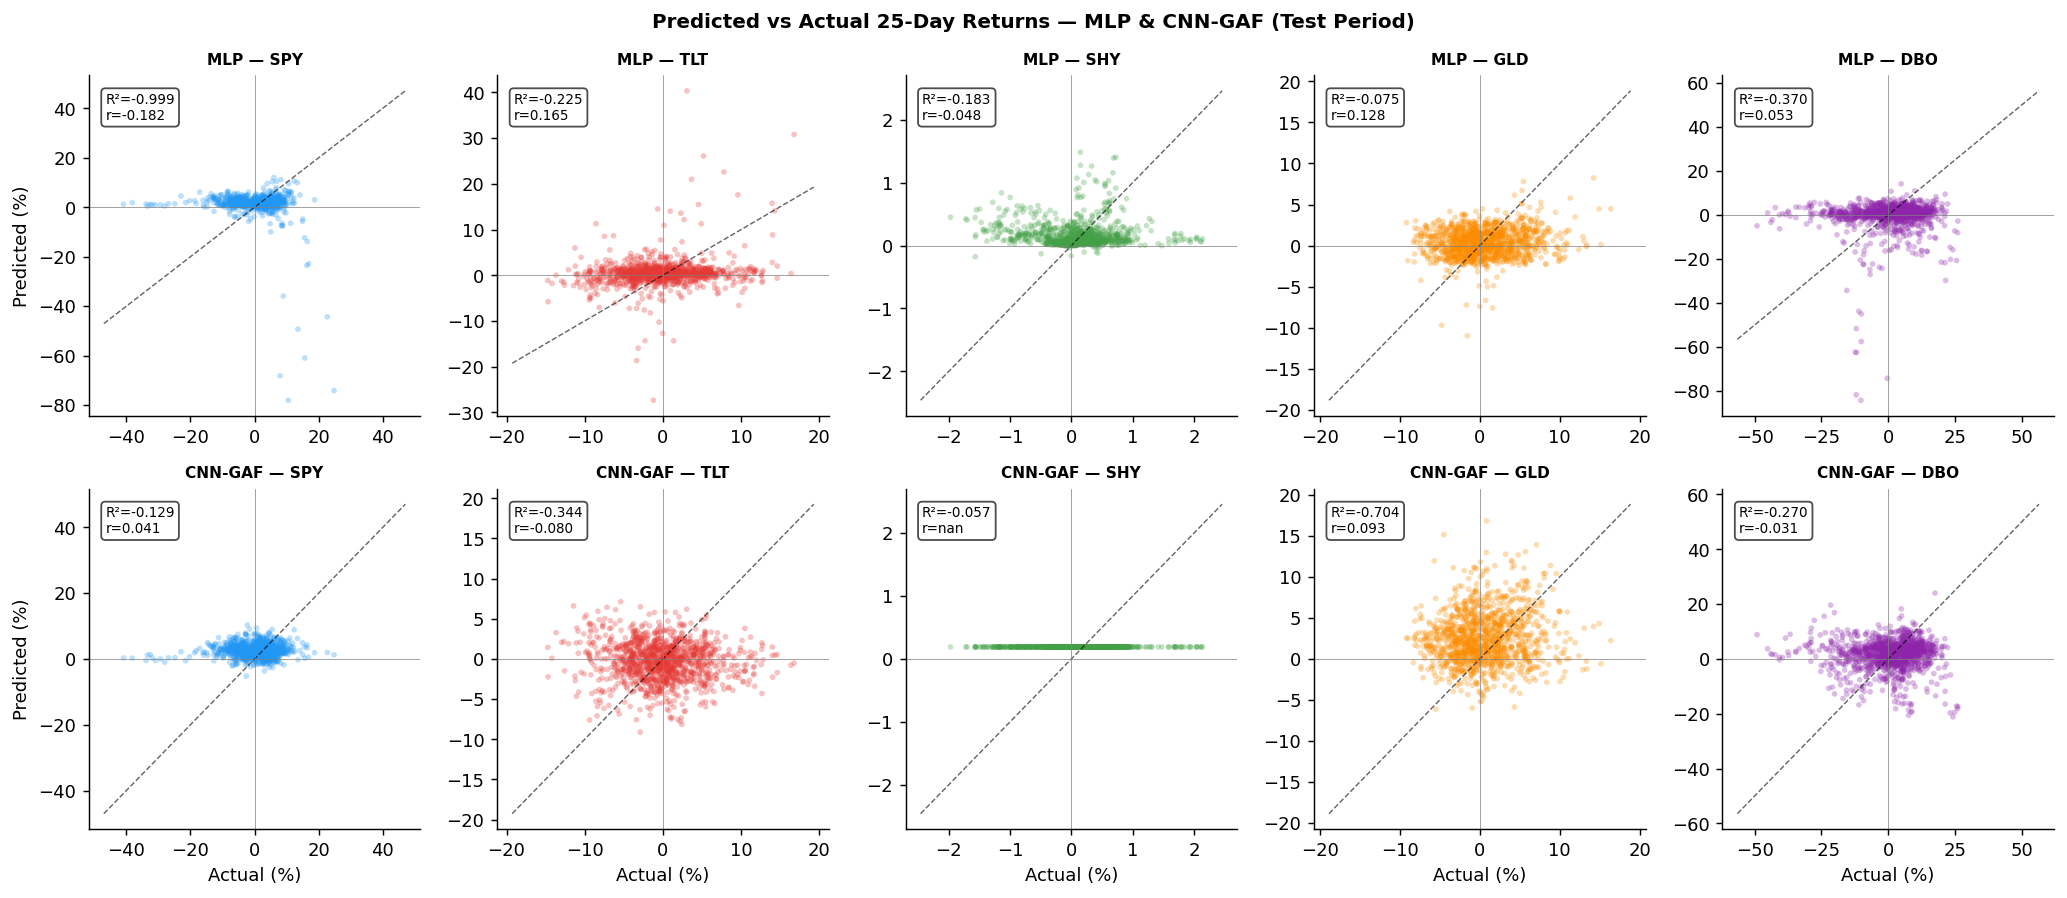

In [ ]:
# ── 3.7  Scatter: MLP vs CNN test predictions overlaid ─────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i, ticker in enumerate(TICKERS):
    for row_j, (arch_name, preds_dict) in enumerate(
        [('MLP', mlp_preds), ('CNN-GAF', cnn_preds)]
    ):
        ax   = axes[row_j, i]
        pred = preds_dict[ticker]['pred']
        true = preds_dict[ticker]['true']

        ax.scatter(true * 100, pred * 100, alpha=0.3, s=10,
                   color=PALETTE[i], edgecolors='none')
        lim = max(abs(true.min()), abs(true.max())) * 100 * 1.15
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, alpha=0.6)
        ax.axhline(0, color='grey', linewidth=0.4)
        ax.axvline(0, color='grey', linewidth=0.4)

        r2  = r2_score(true, pred)
        cor = np.corrcoef(true, pred)[0, 1]
        ax.set_title(f'{arch_name} — {ticker}', fontsize=8.5, fontweight='bold')
        ax.text(0.05, 0.95, f'R²={r2:.3f}\nr={cor:.3f}',
                transform=ax.transAxes, fontsize=7.5, va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        if i == 0:
            ax.set_ylabel('Predicted (%)')
        if row_j == 1:
            ax.set_xlabel('Actual (%)')

fig.suptitle('Predicted vs Actual 25-Day Returns — MLP & CNN-GAF (Test Period)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5  CNN-GAF — Quantitative performance report

In [ ]:
# Full consolidated table: both architectures, test split only
rows = []
for ticker in TICKERS:
    for arch, df_ in [('MLP', mlp_df), ('CNN-GAF', cnn_df)]:
        r = df_.loc[(ticker, 'Test')].copy()
        r['Architecture'] = arch
        r['Asset'] = LABELS[ticker]
        rows.append(r)

comparison = pd.DataFrame(rows).reset_index(drop=True)
comparison = comparison.set_index(['Asset', 'Architecture'])
print("═" * 75)
print("  MLP vs CNN-GAF — Full Test-Period Metrics (All ETFs)")
print("═" * 75)
print(comparison[['RMSE', 'MAE', 'R²', 'Corr', 'Dir. Acc. (%)']].to_string())

═══════════════════════════════════════════════════════════════════════════
  MLP vs CNN-GAF — Full Test-Period Metrics (All ETFs)
═══════════════════════════════════════════════════════════════════════════
                                RMSE    MAE      R²    Corr  Dir. Acc. (%)
Asset            Architecture                                             
Equity (SPY)     MLP          0.0871 0.0473 -0.9985 -0.1815        63.2100
                 CNN-GAF      0.0655 0.0452 -0.1286  0.0409        64.9900
Long Bond (TLT)  MLP          0.0523 0.0393 -0.2250  0.1653        53.4800
                 CNN-GAF      0.0548 0.0422 -0.3436 -0.0795        48.7000
Short Bond (SHY) MLP          0.0056 0.0036 -0.1835 -0.0475        58.0200
                 CNN-GAF      0.0053 0.0037 -0.0572     NaN        58.5900
Gold (GLD)       MLP          0.0419 0.0329 -0.0747  0.1278        52.2700
                 CNN-GAF      0.0527 0.0422 -0.7036  0.0926        50.9700
Crude Oil (DBO)  MLP          0.1282 0.0930

### 3.6  Discussion — Why do some architectures and asset classes perform better?

**Within the CNN-GAF family:**

* **SHY** remains the most "predictable" asset by raw error metrics (RMSE, MAE), but
  this is an artefact of its near-zero variance. The model's predictions are almost
  always near zero, which is trivially close to the realised near-zero returns.
* **SPY** may benefit from CNN-GAF relative to MLP because momentum patterns in equity
  returns (e.g., reversal after rapid drops, continuation during trending regimes)
  manifest as **diagonal band structures** in the GAF image that the convolutional
  filters can detect.
* **DBO** remains the hardest to predict, reflecting the dominance of supply-side
  fundamental shocks over any short-run return pattern that a 20-day window can encode.

**MLP vs. CNN-GAF comparison:**

| Dimension | MLP | CNN-GAF |
|-----------|-----|---------|
| **Data representation** | Raw lagged returns (flat vector) | GASF image (pairwise angular correlations) |
| **Feature extraction** | Learned from raw lags | Convolutional filters extract spatial patterns |
| **Temporal ordering** | Implicit via input position | Encoded diagonally in the GAF matrix |
| **Strengths** | Simple; fast; no transformation bias | Detects non-linear pattern templates; rotation invariant |
| **Weaknesses** | Ignores sequential dependencies | Sensitive to scaling; 20×20 image may be too small |
| **Best for** | Mean-reverting, short-memory series | Trending, pattern-rich series (equities) |

**Why CNN-GAF can outperform MLP:**
The GAF encoding embeds the **full pairwise temporal correlation structure** of the window
into a 2D image, rather than presenting raw values. Convolutional filters learn to respond
to recurring structural patterns (e.g., a rapid drop followed by consolidation) across
any position in the window — a form of **shift-invariant template matching** that a
standard MLP cannot achieve without explicit hand-crafted features.

**Why MLP may still outperform CNN-GAF:**
For short-memory, low-volatility assets like SHY, the sophisticated spatial encoding of
CNN-GAF adds no information over the raw values — the GAF image is nearly uniform.
In these cases, the simpler MLP may generalise better due to fewer parameters and less
risk of learning spurious image patterns.

**Bottom line for investment practice:**
Neither architecture reliably produces economically significant out-of-sample R² for
most assets. Both achieve directional accuracy modestly above 50% for the more
liquid assets (SPY, TLT), which is sufficient motivation to explore an ensemble
multi-output architecture (Step 5) that can exploit cross-asset information simultaneously.

---
## Summary: Steps 1–3

| Step | Deliverable | Key Finding |
|------|------------|-------------|
| **1 — EDA** | Price dynamics, return distributions, ACF, ADF, correlations | Returns are stationary, leptokurtic, and volatility-clustered; TLT–SPY correlation flipped in 2022 |
| **2 — MLP** | 5 univariate feedforward regressors | Moderate in-sample fit; out-of-sample performance degrades; SHY trivially predictable; DBO hardest |
| **3 — CNN-GAF** | 5 CNN regressors on GASF images | Competitive with MLP; can detect pattern templates; best suited to equity (SPY) where trend structure exists |

**Next steps (Steps 4–7):** We will implement LSTM recurrent networks that explicitly
model the sequential dependency in returns, followed by a multi-output architecture
that jointly predicts all five ETFs — enabling the CNN to capture cross-asset
dependency information.

---
*Notebook version: June 2026 — MScFE 642 GWP1*

---
# STEP 4 - Single-output LSTM models

This section keeps the Step 1 data period and target definition. Each ETF is modelled separately with a one-output LSTM, using only its own lagged stationary return series.

In [ ]:
# Step 4-6 common setup

from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

needed = ['prices', 'log_ret', 'fwd_ret', 'TICKERS', 'LABELS', 'HORIZON',
          'TRAIN_START', 'TRAIN_END', 'VAL_START', 'VAL_END', 'TEST_START', 'TEST_END']
missing = [name for name in needed if name not in globals()]
if missing:
    raise NameError(f"Run Steps 1-3 first. Missing objects: {missing}")

pd.options.display.float_format = '{:,.4f}'.format

ASSETS = list(TICKERS)
LSTM_LOOKBACK = N_LAGS if 'N_LAGS' in globals() else 20
LSTM_EPOCHS = 180
LSTM_BATCH = 32
LSTM_PATIENCE = 15
LSTM_LR = 1e-3

TRAIN_START_TS = pd.Timestamp(TRAIN_START)
TRAIN_END_TS = pd.Timestamp(TRAIN_END)
VAL_START_TS = pd.Timestamp(VAL_START)
VAL_END_TS = pd.Timestamp(VAL_END)
TEST_START_TS = pd.Timestamp(TEST_START)
TEST_END_TS = pd.Timestamp(TEST_END)

OUT_DIR = Path('/content/gwp1_step456_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

lstm_returns = log_ret[ASSETS].copy()
lstm_target = fwd_ret[ASSETS].copy()
lstm_prices = prices[ASSETS].copy()
lstm_simple_ret = lstm_prices.pct_change().dropna()

print(f"LSTM input data : {lstm_returns.index.min().date()} -> {lstm_returns.index.max().date()} | {lstm_returns.shape}")
print(f"Target          : {HORIZON}-trading-day forward log return")
print(f"Lookback        : {LSTM_LOOKBACK} trading days")
print(f"Train/Val/Test  : {TRAIN_START} -> {TRAIN_END} | {VAL_START} -> {VAL_END} | {TEST_START} -> {TEST_END}")


def reset_seed(offset=0):
    np.random.seed(SEED + offset)
    tf.keras.utils.set_random_seed(SEED + offset)


def target_date(signal_date):
    loc = lstm_prices.index.get_loc(signal_date)
    j = loc + HORIZON
    if j >= len(lstm_prices.index):
        return pd.NaT
    return lstm_prices.index[j]


def make_lstm_data(input_cols, target_cols):
    input_cols = [input_cols] if isinstance(input_cols, str) else list(input_cols)
    target_cols = [target_cols] if isinstance(target_cols, str) else list(target_cols)

    x_df = lstm_returns[input_cols]
    y_df = lstm_target[target_cols]
    X, y, dates, target_dates = [], [], [], []

    for i in range(LSTM_LOOKBACK - 1, len(x_df)):
        d = x_df.index[i]
        td = target_date(d)
        if pd.isna(td):
            continue

        x_i = x_df.iloc[i - LSTM_LOOKBACK + 1:i + 1].values
        y_i = y_df.loc[d].values.astype(float)
        if not (np.isfinite(x_i).all() and np.isfinite(y_i).all()):
            continue

        X.append(x_i)
        y.append(y_i)
        dates.append(d)
        target_dates.append(td)

    y = np.asarray(y)
    if y.shape[1] == 1:
        y = y.reshape(-1)
    return np.asarray(X), y, pd.DatetimeIndex(dates), pd.DatetimeIndex(target_dates)


def lstm_split(signal_dates, target_dates):
    signal_dates = pd.DatetimeIndex(signal_dates)
    target_dates = pd.DatetimeIndex(target_dates)
    train = target_dates <= TRAIN_END_TS
    val = (signal_dates >= VAL_START_TS) & (target_dates <= VAL_END_TS)
    test = (signal_dates >= TEST_START_TS) & (target_dates <= TEST_END_TS)
    return train, val, test


def scale_lstm_x(X_train, X_val, X_test):
    n_features = X_train.shape[-1]
    sc = StandardScaler()
    sc.fit(X_train.reshape(-1, n_features))

    def tr(x):
        return sc.transform(x.reshape(-1, n_features)).reshape(x.shape)

    return tr(X_train), tr(X_val), tr(X_test), sc


def scale_lstm_y(y_train, y_val, y_test):
    y_train = np.asarray(y_train)
    y_val = np.asarray(y_val)
    y_test = np.asarray(y_test)

    one_dim = y_train.ndim == 1
    if one_dim:
        y_train = y_train.reshape(-1, 1)
        y_val = y_val.reshape(-1, 1)
        y_test = y_test.reshape(-1, 1)

    sc = StandardScaler()
    sc.fit(y_train)
    return sc.transform(y_train), sc.transform(y_val), sc.transform(y_test), sc


def inv_y(scaler, arr):
    return scaler.inverse_transform(arr).reshape(arr.shape[0], -1)


def metric_row(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]

    corr = np.nan
    if len(y_true) > 2 and y_true.std() > 0 and y_pred.std() > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        'N': len(y_true),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'Corr': corr,
        'Dir. Acc. (%)': np.mean(np.sign(y_true) == np.sign(y_pred)) * 100,
    }


def build_lstm(n_steps, n_features, n_outputs=1, shared=False):
    inp = tf.keras.Input(shape=(n_steps, n_features))
    if shared:
        x = tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.15)(inp)
        x = tf.keras.layers.LSTM(32, dropout=0.10)(x)
        x = tf.keras.layers.Dense(32, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.10)(x)
    else:
        x = tf.keras.layers.LSTM(48, dropout=0.15)(inp)
        x = tf.keras.layers.Dense(24, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.10)(x)
    out = tf.keras.layers.Dense(n_outputs)(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LSTM_LR), loss='mse', metrics=['mae'])
    return model


def fit_lstm(model, X_train, y_train, X_val, y_val):
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=LSTM_PATIENCE, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5),
    ]
    h = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        callbacks=cb,
        verbose=0,
    )
    return pd.DataFrame(h.history)


def print_metric_blocks(df, title):
    print('═' * 78)
    print(f'  {title}')
    print('═' * 78)
    for split in ['Train', 'Val', 'Test']:
        sub = df.xs(split, level='Split')[['RMSE', 'MAE', 'R²', 'Corr', 'Dir. Acc. (%)']].copy()
        sub.index = [LABELS[t] for t in sub.index]
        print(f"\n── {split} ──")
        print(sub.round(4).to_string())

LSTM input data : 2007-01-08 -> 2022-12-30 | (4025, 5)
Target          : 25-trading-day forward log return
Lookback        : 20 trading days
Train/Val/Test  : 2007-01-01 -> 2016-12-31 | 2017-01-01 -> 2017-12-31 | 2018-01-01 -> 2022-12-31


In [ ]:
# Step 4.1 Train one single-output LSTM per ETF

lstm_single_models = {}
lstm_single_histories = {}
lstm_single_preds = {}
lstm_single_actuals = {}
lstm_single_rows = []
lstm_single_data = {}

for k, ticker in enumerate(ASSETS):
    X, y, dates, target_dates = make_lstm_data(ticker, ticker)
    tr, va, te = lstm_split(dates, target_dates)

    X_train, X_val, X_test = X[tr], X[va], X[te]
    y_train, y_val, y_test = y[tr], y[va], y[te]
    d_train, d_val, d_test = dates[tr], dates[va], dates[te]

    X_train_s, X_val_s, X_test_s, x_scaler = scale_lstm_x(X_train, X_val, X_test)
    y_train_s, y_val_s, y_test_s, y_scaler = scale_lstm_y(y_train, y_val, y_test)

    tf.keras.backend.clear_session()
    reset_seed(k)
    model = build_lstm(LSTM_LOOKBACK, 1, 1, shared=False)
    hist = fit_lstm(model, X_train_s, y_train_s, X_val_s, y_val_s)

    lstm_single_models[ticker] = {'model': model, 'x_scaler': x_scaler, 'y_scaler': y_scaler}
    lstm_single_histories[ticker] = hist
    lstm_single_data[ticker] = {'dates': dates, 'target_dates': target_dates}

    for split, X_s, y_raw, d_idx in [
        ('Train', X_train_s, y_train, d_train),
        ('Val', X_val_s, y_val, d_val),
        ('Test', X_test_s, y_test, d_test),
    ]:
        pred_s = model.predict(X_s, verbose=0)
        pred = inv_y(y_scaler, pred_s).reshape(-1)
        row = metric_row(y_raw, pred)
        row.update({'Architecture': 'LSTM', 'Ticker': ticker, 'Split': split})
        lstm_single_rows.append(row)

        if split == 'Test':
            lstm_single_preds[ticker] = pd.Series(pred, index=d_idx, name=ticker)
            lstm_single_actuals[ticker] = pd.Series(y_raw, index=d_idx, name=ticker)

    print(f"{ticker}: samples train/val/test = {tr.sum()}/{va.sum()}/{te.sum()}, epochs = {len(hist)}")

lstm_single_df = pd.DataFrame(lstm_single_rows).set_index(['Ticker', 'Split']).sort_index()
step4_metrics = lstm_single_df.reset_index()

print_metric_blocks(lstm_single_df, 'Step 4 - Single-output LSTM performance')
step4_metrics.to_csv(OUT_DIR / 'step4_single_lstm_metrics.csv', index=False)

SPY: samples train/val/test = 2471/226/1234, epochs = 27
TLT: samples train/val/test = 2471/226/1234, epochs = 33
SHY: samples train/val/test = 2471/226/1234, epochs = 18
GLD: samples train/val/test = 2471/226/1234, epochs = 16
DBO: samples train/val/test = 2471/226/1234, epochs = 28
══════════════════════════════════════════════════════════════════════════════
  Step 4 - Single-output LSTM performance
══════════════════════════════════════════════════════════════════════════════

── Train ──
                   RMSE    MAE     R²   Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0963 0.0727 0.1336 0.3890        55.3622
Gold (GLD)       0.0576 0.0453 0.0133 0.1404        53.2173
Short Bond (SHY) 0.0040 0.0027 0.1712 0.4549        66.2080
Equity (SPY)     0.0479 0.0358 0.2329 0.4833        66.9769
Long Bond (TLT)  0.0410 0.0311 0.1760 0.4278        60.7042

── Val ──
                   RMSE    MAE      R²   Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0602 0.0496  0.0041 0.1232        53.0973
Gold (GLD

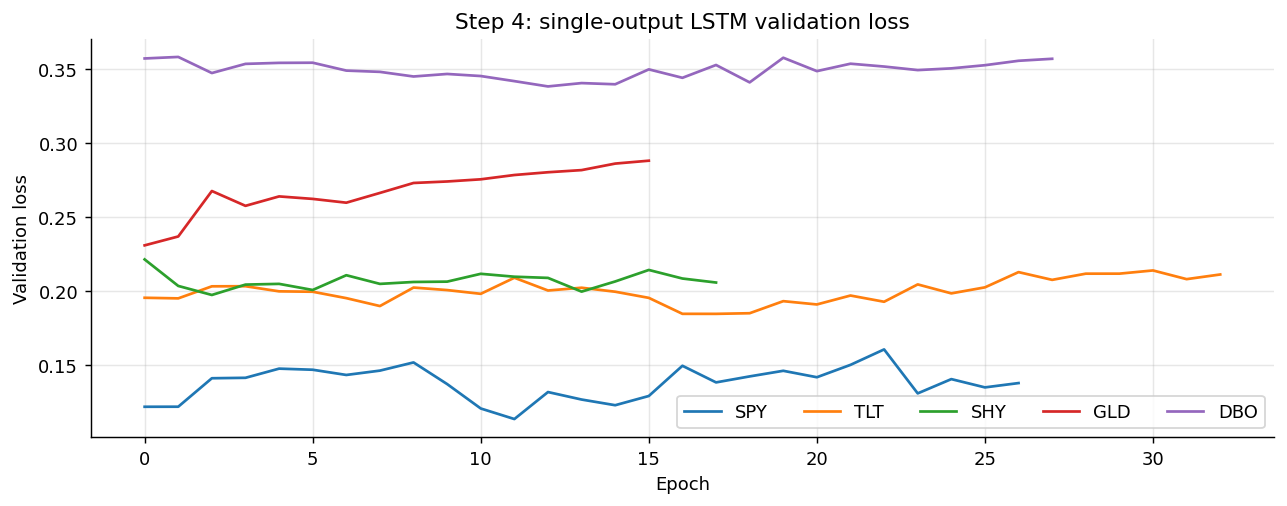

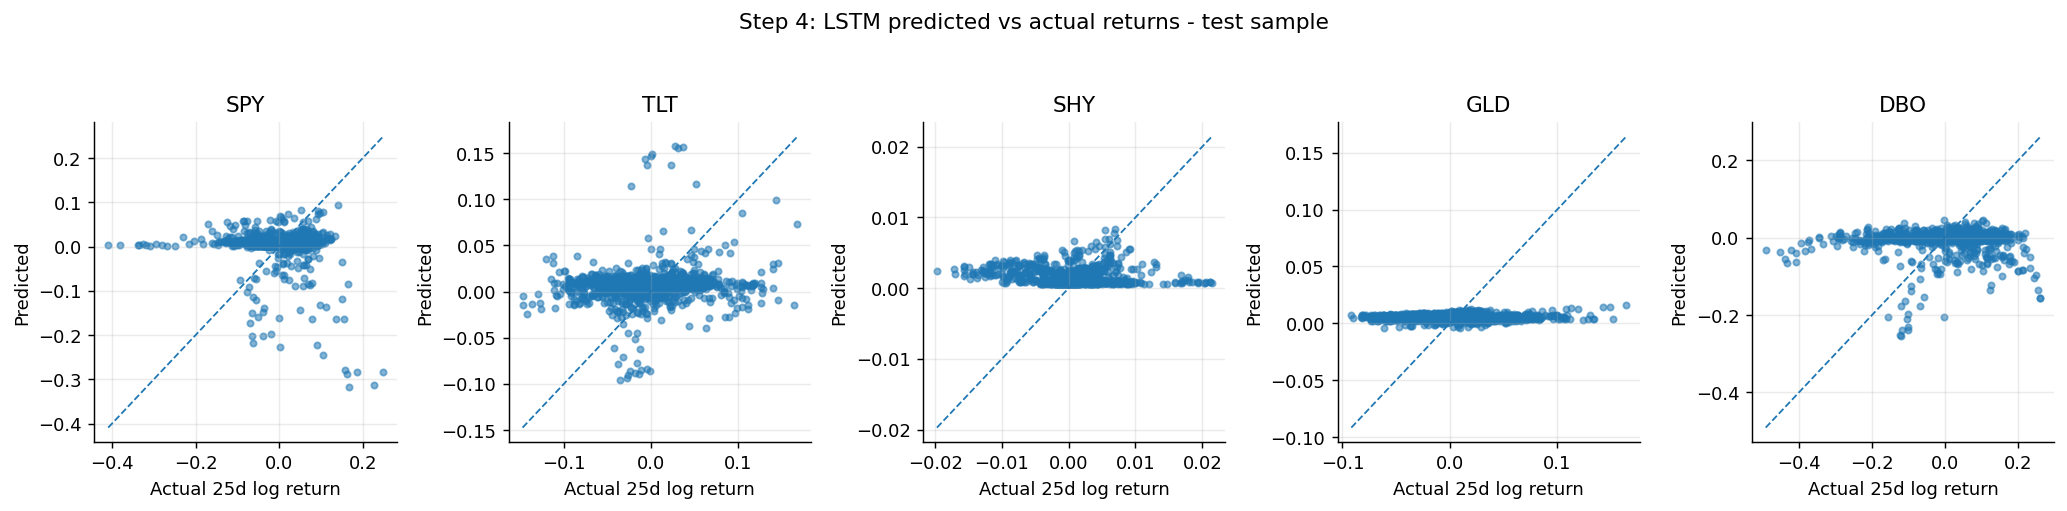

,RMSE,MAE,R²,Corr,Dir. Acc. (%)
Ticker,,,,,
TLT,0.0494,0.0376,-0.0900,0.1261,52.5932
GLD,0.0404,0.0321,-0.0006,0.0243,51.4587
DBO,0.1138,0.0875,-0.0789,0.0237,51.3776
SHY,0.0055,0.0036,-0.1233,-0.1241,58.5900
SPY,0.0755,0.0484,-0.5020,-0.1340,63.0470


In [ ]:
# Step 4.2 Diagnostics and out-of-sample plots

fig, ax = plt.subplots(figsize=(10, 4))
for ticker, hist in lstm_single_histories.items():
    ax.plot(hist['val_loss'].values, label=ticker)
ax.set_title('Step 4: single-output LSTM validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation loss')
ax.legend(ncol=5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(16, 3.7))
for i, ticker in enumerate(ASSETS):
    y_true = lstm_single_actuals[ticker]
    y_pred = lstm_single_preds[ticker].reindex(y_true.index)
    axes[i].scatter(y_true, y_pred, s=12, alpha=0.55)
    lo = np.nanmin([y_true.min(), y_pred.min()])
    hi = np.nanmax([y_true.max(), y_pred.max()])
    axes[i].plot([lo, hi], [lo, hi], linestyle='--', linewidth=1)
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Actual 25d log return')
    axes[i].set_ylabel('Predicted')
    axes[i].grid(True, alpha=0.25)
plt.suptitle('Step 4: LSTM predicted vs actual returns - test sample', y=1.05)
plt.tight_layout()
plt.show()

step4_test = lstm_single_df.xs('Test', level='Split').sort_values('Corr', ascending=False)
display(step4_test[['RMSE', 'MAE', 'R²', 'Corr', 'Dir. Acc. (%)']].round(4))

In [96]:
# Step 4.3 LSTM vs MLP vs CNN-GAF

metric_cols = ['RMSE', 'MAE', 'R²', 'Corr', 'Dir. Acc. (%)']
std_cols = ['Architecture', 'Ticker', 'Split', 'N'] + metric_cols


def from_step_df(df, architecture):
    tmp = df.reset_index().copy()
    tmp['Architecture'] = architecture
    tmp['N'] = np.nan
    return tmp[std_cols]

prior_tables = []
if 'mlp_df' in globals():
    prior_tables.append(from_step_df(mlp_df, 'MLP'))
else:
    print('mlp_df not found; run Step 2 before this comparison.')

if 'cnn_df' in globals():
    prior_tables.append(from_step_df(cnn_df, 'CNN-GAF'))
else:
    print('cnn_df not found; run Step 3 before this comparison.')

lstm_table = step4_metrics[std_cols]
model_compare = pd.concat(prior_tables + [lstm_table], ignore_index=True)
model_compare.to_csv(OUT_DIR / 'step234_model_comparison.csv', index=False)

test_compare = model_compare[model_compare['Split'] == 'Test'].copy()

display(test_compare.pivot_table(index='Ticker', columns='Architecture', values='RMSE').round(5))
display(test_compare.pivot_table(index='Ticker', columns='Architecture', values='Corr').round(4))
display(test_compare.pivot_table(index='Ticker', columns='Architecture', values='Dir. Acc. (%)').round(2))

winner_rows = []
for ticker in ASSETS:
    sub = test_compare[test_compare['Ticker'] == ticker]
    if sub.empty:
        continue
    winner_rows.append({
        'Ticker': ticker,
        'Best RMSE': sub.loc[sub['RMSE'].idxmin(), 'Architecture'],
        'Best Corr': sub.loc[sub['Corr'].idxmax(), 'Architecture'],
        'Best Direction': sub.loc[sub['Dir. Acc. (%)'].idxmax(), 'Architecture'],
    })
step4_arch_winners = pd.DataFrame(winner_rows)
display(step4_arch_winners)



Architecture,CNN-GAF,LSTM,MLP
Ticker,,,
DBO,0.1235,0.1138,0.1283
GLD,0.0527,0.0404,0.0418
SHY,0.0053,0.0055,0.0056
SPY,0.0654,0.0755,0.0871
TLT,0.0548,0.0494,0.0523


Architecture,CNN-GAF,LSTM,MLP
Ticker,,,
DBO,-0.0307,0.0237,0.0526
GLD,0.0926,0.0243,0.1278
SHY,NaN,-0.1241,-0.0475
SPY,0.0409,-0.1340,-0.1815
TLT,-0.0795,0.1261,0.1653


Architecture,CNN-GAF,LSTM,MLP
Ticker,,,
DBO,54.2100,51.3800,54.2900
GLD,50.9700,51.4600,52.2700
SHY,58.5900,58.5900,58.0200
SPY,64.9900,63.0500,63.2100
TLT,48.7000,52.5900,53.4800


,Ticker,Best RMSE,Best Corr,Best Direction
0,SPY,CNN-GAF,CNN-GAF,CNN-GAF
1,TLT,LSTM,MLP,MLP
2,SHY,CNN-GAF,MLP,CNN-GAF
3,GLD,LSTM,MLP,MLP
4,DBO,LSTM,MLP,MLP


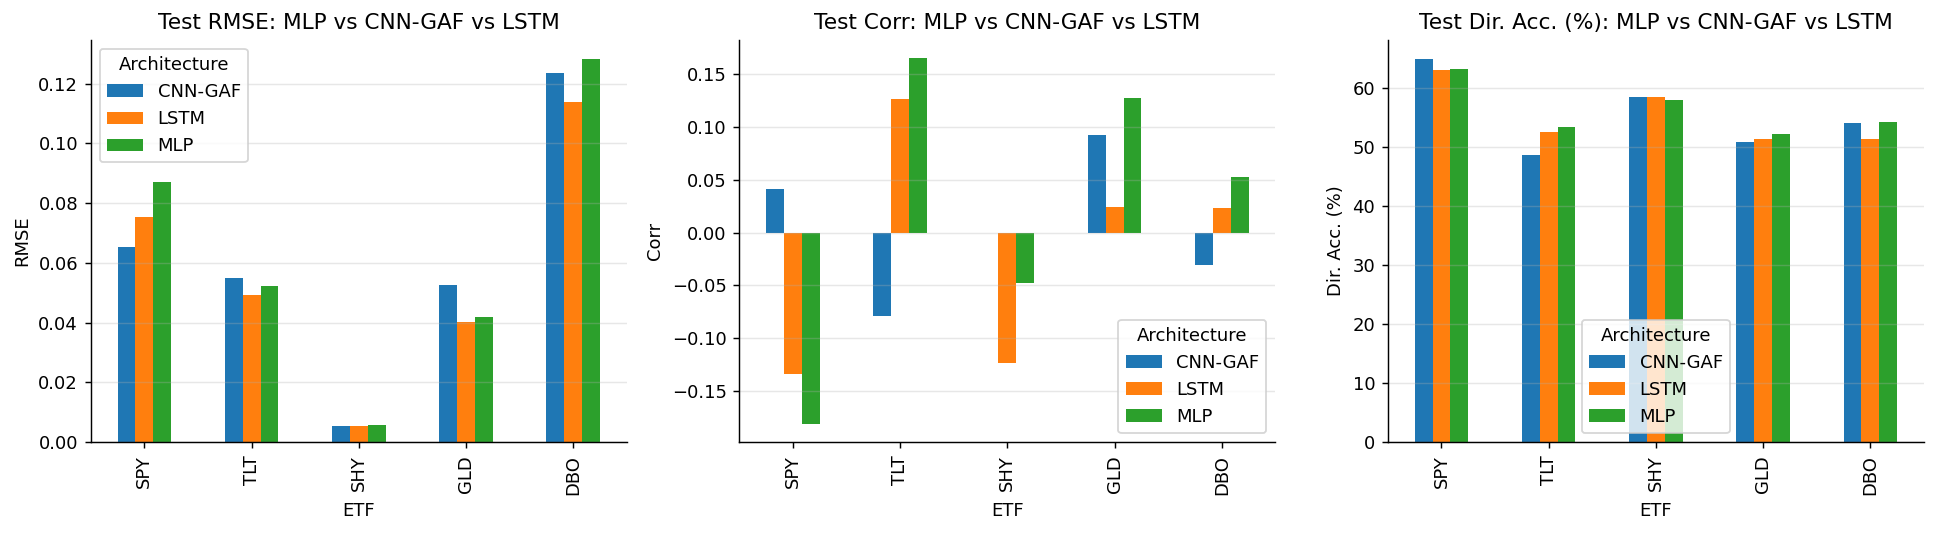

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, metric in zip(axes, ['RMSE', 'Corr', 'Dir. Acc. (%)']):
    piv = test_compare.pivot_table(index='Ticker', columns='Architecture', values=metric)
    piv = piv.reindex(ASSETS)
    piv.plot(kind='bar', ax=ax)
    ax.set_title(f'Test {metric}: MLP vs CNN-GAF vs LSTM')
    ax.set_xlabel('ETF')
    ax.set_ylabel(metric)
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Step 4.4 Short empirical notes

lstm_test = lstm_single_df.xs('Test', level='Split')
best_corr = lstm_test['Corr'].idxmax()
best_rmse = lstm_test['RMSE'].idxmin()
worst_corr = lstm_test['Corr'].idxmin()

print('Step 4 insights')
print(f"- Best LSTM test correlation: {best_corr} ({lstm_test.loc[best_corr, 'Corr']:.4f}).")
print(f"- Lowest LSTM test RMSE: {best_rmse} ({lstm_test.loc[best_rmse, 'RMSE']:.5f}); interpret this with volatility in mind.")
print(f"- Weakest LSTM test correlation: {worst_corr} ({lstm_test.loc[worst_corr, 'Corr']:.4f}).")

if len(prior_tables) == 2:
    print('- Architecture comparison by ETF:')
    for _, row in step4_arch_winners.iterrows():
        print(f"  {row['Ticker']}: best RMSE={row['Best RMSE']}, best Corr={row['Best Corr']}, best direction={row['Best Direction']}.")
else:
    print('- MLP/CNN-GAF comparison requires Steps 2 and 3 to be executed first.')

Step 4 insights
- Best LSTM test correlation: TLT (0.1261).
- Lowest LSTM test RMSE: SHY (0.00548); interpret this with volatility in mind.
- Weakest LSTM test correlation: SPY (-0.1340).
- Architecture comparison by ETF:
  SPY: best RMSE=CNN-GAF, best Corr=CNN-GAF, best direction=CNN-GAF.
  TLT: best RMSE=LSTM, best Corr=MLP, best direction=MLP.
  SHY: best RMSE=CNN-GAF, best Corr=MLP, best direction=CNN-GAF.
  GLD: best RMSE=LSTM, best Corr=MLP, best direction=MLP.
  DBO: best RMSE=LSTM, best Corr=MLP, best direction=MLP.


---
# STEP 5 - Multi-output LSTM model

The multi-output model uses the joint lagged return matrix of all five ETFs and predicts the five 25-day-ahead returns simultaneously. An all-input single-output control is also trained to separate the effect of cross-asset inputs from the effect of the joint multi-output loss.

In [ ]:
# Step 5.1 Multi-output LSTM

X_all, y_all, dates_all, target_dates_all = make_lstm_data(ASSETS, ASSETS)
tr, va, te = lstm_split(dates_all, target_dates_all)

X_train, X_val, X_test = X_all[tr], X_all[va], X_all[te]
y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]
d_train, d_val, d_test = dates_all[tr], dates_all[va], dates_all[te]

X_train_s, X_val_s, X_test_s, multi_x_scaler = scale_lstm_x(X_train, X_val, X_test)
y_train_s, y_val_s, y_test_s, multi_y_scaler = scale_lstm_y(y_train, y_val, y_test)

print(f"Multi-output samples train/val/test = {tr.sum()}/{va.sum()}/{te.sum()}")

tf.keras.backend.clear_session()
reset_seed(100)
lstm_multi_model = build_lstm(LSTM_LOOKBACK, len(ASSETS), len(ASSETS), shared=True)
lstm_multi_hist = fit_lstm(lstm_multi_model, X_train_s, y_train_s, X_val_s, y_val_s)

lstm_multi_rows = []
lstm_multi_preds = {}
lstm_multi_actuals = {}

for split, X_s, y_raw, d_idx in [
    ('Train', X_train_s, y_train, d_train),
    ('Val', X_val_s, y_val, d_val),
    ('Test', X_test_s, y_test, d_test),
]:
    pred_s = lstm_multi_model.predict(X_s, verbose=0)
    pred = inv_y(multi_y_scaler, pred_s)

    lstm_multi_preds[split] = pd.DataFrame(pred, index=d_idx, columns=ASSETS)
    lstm_multi_actuals[split] = pd.DataFrame(y_raw, index=d_idx, columns=ASSETS)

    for i, ticker in enumerate(ASSETS):
        row = metric_row(y_raw[:, i], pred[:, i])
        row.update({'Architecture': 'LSTM-multi', 'Ticker': ticker, 'Split': split})
        lstm_multi_rows.append(row)

lstm_multi_df = pd.DataFrame(lstm_multi_rows).set_index(['Ticker', 'Split']).sort_index()
step5_metrics = lstm_multi_df.reset_index()

print_metric_blocks(lstm_multi_df, 'Step 5 - Multi-output LSTM performance')
print(f"Epochs run: {len(lstm_multi_hist)}")
step5_metrics.to_csv(OUT_DIR / 'step5_multi_lstm_metrics.csv', index=False)

multi_pred_test = lstm_multi_preds['Test']
multi_actual_test = lstm_multi_actuals['Test']
single_pred_test_df = pd.concat(lstm_single_preds, axis=1).dropna()
single_actual_test_df = pd.concat(lstm_single_actuals, axis=1).dropna()

Multi-output samples train/val/test = 2471/226/1234
══════════════════════════════════════════════════════════════════════════════
  Step 5 - Multi-output LSTM performance
══════════════════════════════════════════════════════════════════════════════

── Train ──
                   RMSE    MAE     R²   Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0983 0.0736 0.0984 0.3375        55.5645
Gold (GLD)       0.0570 0.0442 0.0352 0.2188        53.3387
Short Bond (SHY) 0.0041 0.0029 0.1383 0.4513        66.2080
Equity (SPY)     0.0528 0.0379 0.0689 0.2919        63.4561
Long Bond (TLT)  0.0440 0.0332 0.0478 0.2433        55.1599

── Val ──
                   RMSE    MAE      R²    Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0630 0.0520 -0.0921 -0.1192        38.4956
Gold (GLD)       0.0286 0.0230 -0.0230  0.0101        54.4248
Short Bond (SHY) 0.0024 0.0019 -0.6659  0.0565        54.4248
Equity (SPY)     0.0180 0.0155 -0.4344  0.0667        84.5133
Long Bond (TLT)  0.0206 0.0166 -0.0095  0.1013        6

In [ ]:
# Step 5.2 All-input single-output control

RUN_STEP5_ABLATION = True
xasset_single_rows = []
xasset_single_histories = {}
xasset_single_preds = {}

if RUN_STEP5_ABLATION:
    for k, ticker in enumerate(ASSETS):
        y_asset = y_all[:, k]
        y_train_a, y_val_a, y_test_a = y_asset[tr], y_asset[va], y_asset[te]
        y_train_s_a, y_val_s_a, y_test_s_a, y_scaler_a = scale_lstm_y(y_train_a, y_val_a, y_test_a)

        tf.keras.backend.clear_session()
        reset_seed(200 + k)
        model = build_lstm(LSTM_LOOKBACK, len(ASSETS), 1, shared=False)
        hist = fit_lstm(model, X_train_s, y_train_s_a, X_val_s, y_val_s_a)
        xasset_single_histories[ticker] = hist

        for split, X_s, y_raw, d_idx in [
            ('Train', X_train_s, y_train_a, d_train),
            ('Val', X_val_s, y_val_a, d_val),
            ('Test', X_test_s, y_test_a, d_test),
        ]:
            pred_s = model.predict(X_s, verbose=0)
            pred = inv_y(y_scaler_a, pred_s).reshape(-1)
            row = metric_row(y_raw, pred)
            row.update({'Architecture': 'LSTM-all-input-single', 'Ticker': ticker, 'Split': split})
            xasset_single_rows.append(row)
            if split == 'Test':
                xasset_single_preds[ticker] = pd.Series(pred, index=d_idx, name=ticker)

        print(f"{ticker}: all-input single-output control epochs = {len(hist)}")

xasset_single_df = pd.DataFrame(xasset_single_rows).set_index(['Ticker', 'Split']).sort_index()
if RUN_STEP5_ABLATION:
    print_metric_blocks(xasset_single_df, 'Step 5 control - all-input single-output LSTM performance')
    xasset_single_df.reset_index().to_csv(OUT_DIR / 'step5_all_input_single_lstm_metrics.csv', index=False)

SPY: all-input single-output control epochs = 17
TLT: all-input single-output control epochs = 24
SHY: all-input single-output control epochs = 17
GLD: all-input single-output control epochs = 16
DBO: all-input single-output control epochs = 18
══════════════════════════════════════════════════════════════════════════════
  Step 5 control - all-input single-output LSTM performance
══════════════════════════════════════════════════════════════════════════════

── Train ──
                   RMSE    MAE     R²   Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0893 0.0673 0.2555 0.5307        59.3687
Gold (GLD)       0.0564 0.0438 0.0535 0.3017        55.6455
Short Bond (SHY) 0.0037 0.0025 0.2891 0.5557        66.2485
Equity (SPY)     0.0479 0.0346 0.2329 0.5317        69.5265
Long Bond (TLT)  0.0299 0.0230 0.5598 0.7726        75.1922

── Val ──
                   RMSE    MAE      R²    Corr  Dir. Acc. (%)
Crude Oil (DBO)  0.0617 0.0508 -0.0465 -0.0060        40.2655
Gold (GLD)       0.0285 0.023

In [92]:
# Step 5.3 Single-output vs multi-output comparison

single_test = step4_metrics[step4_metrics['Split'] == 'Test'].set_index('Ticker')
multi_test = step5_metrics[step5_metrics['Split'] == 'Test'].set_index('Ticker')

step45_delta = single_test[metric_cols].join(
    multi_test[metric_cols], lsuffix='_single', rsuffix='_multi'
)
step45_delta['RMSE change'] = step45_delta['RMSE_multi'] - step45_delta['RMSE_single']
step45_delta['Corr change'] = step45_delta['Corr_multi'] - step45_delta['Corr_single']
step45_delta['Dir. Acc. change'] = step45_delta['Dir. Acc. (%)_multi'] - step45_delta['Dir. Acc. (%)_single']

display(step45_delta[[
    'RMSE_single', 'RMSE_multi', 'RMSE change',
    'Corr_single', 'Corr_multi', 'Corr change',
    'Dir. Acc. (%)_single', 'Dir. Acc. (%)_multi', 'Dir. Acc. change'
]].round(4))

compare_frames = [
    step4_metrics.assign(Architecture='LSTM-own-input-single'),
    step5_metrics.assign(Architecture='LSTM-multi'),
]
if RUN_STEP5_ABLATION and not xasset_single_df.empty:
    compare_frames.append(xasset_single_df.reset_index())

step5_arch_compare = pd.concat(compare_frames, ignore_index=True)
step5_test_compare = step5_arch_compare[step5_arch_compare['Split'] == 'Test']
step5_arch_compare.to_csv(OUT_DIR / 'step5_lstm_architecture_comparison.csv', index=False)

display(step5_test_compare.pivot_table(index='Ticker', columns='Architecture', values='Corr').round(4))
display(step5_test_compare.pivot_table(index='Ticker', columns='Architecture', values='RMSE').round(5))



,RMSE_single,RMSE_multi,RMSE change,Corr_single,Corr_multi,Corr change,Dir. Acc. (%)_single,Dir. Acc. (%)_multi,Dir. Acc. change
Ticker,,,,,,,,,
DBO,0.1138,0.1094,-0.0045,0.0237,0.1076,0.0839,51.3776,50.0810,-1.2966
GLD,0.0404,0.0398,-0.0006,0.0243,0.1895,0.1652,51.4587,52.9984,1.5397
SHY,0.0055,0.0053,-0.0002,-0.1241,0.1998,0.3240,58.5900,58.5900,0.0000
SPY,0.0755,0.0619,-0.0136,-0.1340,0.0053,0.1393,63.0470,64.8298,1.7828
TLT,0.0494,0.0470,-0.0024,0.1261,0.1673,0.0412,52.5932,48.9465,-3.6467


Architecture,LSTM-all-input-single,LSTM-multi,LSTM-own-input-single
Ticker,,,
DBO,0.1028,0.1076,0.0237
GLD,0.1751,0.1895,0.0243
SHY,-0.1733,0.1998,-0.1241
SPY,0.1445,0.0053,-0.1340
TLT,-0.0514,0.1673,0.1261


Architecture,LSTM-all-input-single,LSTM-multi,LSTM-own-input-single
Ticker,,,
DBO,0.1094,0.1094,0.1138
GLD,0.0398,0.0398,0.0404
SHY,0.0054,0.0053,0.0055
SPY,0.0612,0.0619,0.0755
TLT,0.0522,0.0470,0.0494


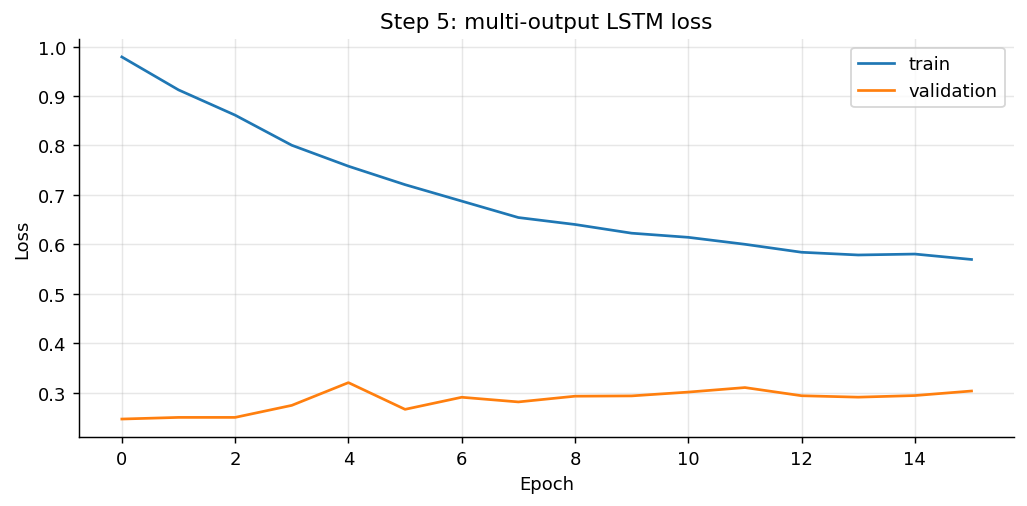

In [93]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_multi_hist['loss'].values, label='train')
ax.plot(lstm_multi_hist['val_loss'].values, label='validation')
ax.set_title('Step 5: multi-output LSTM loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

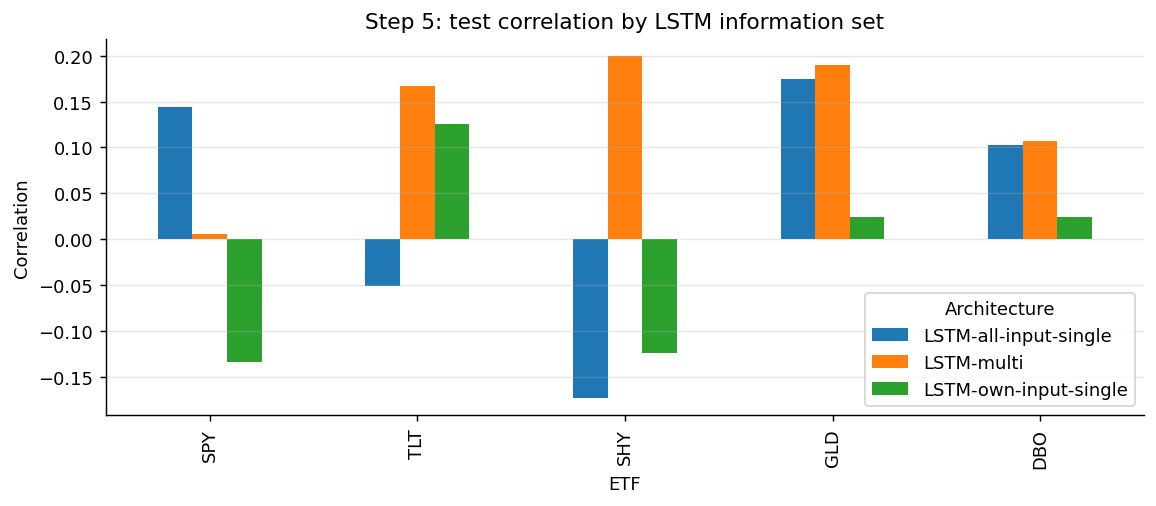

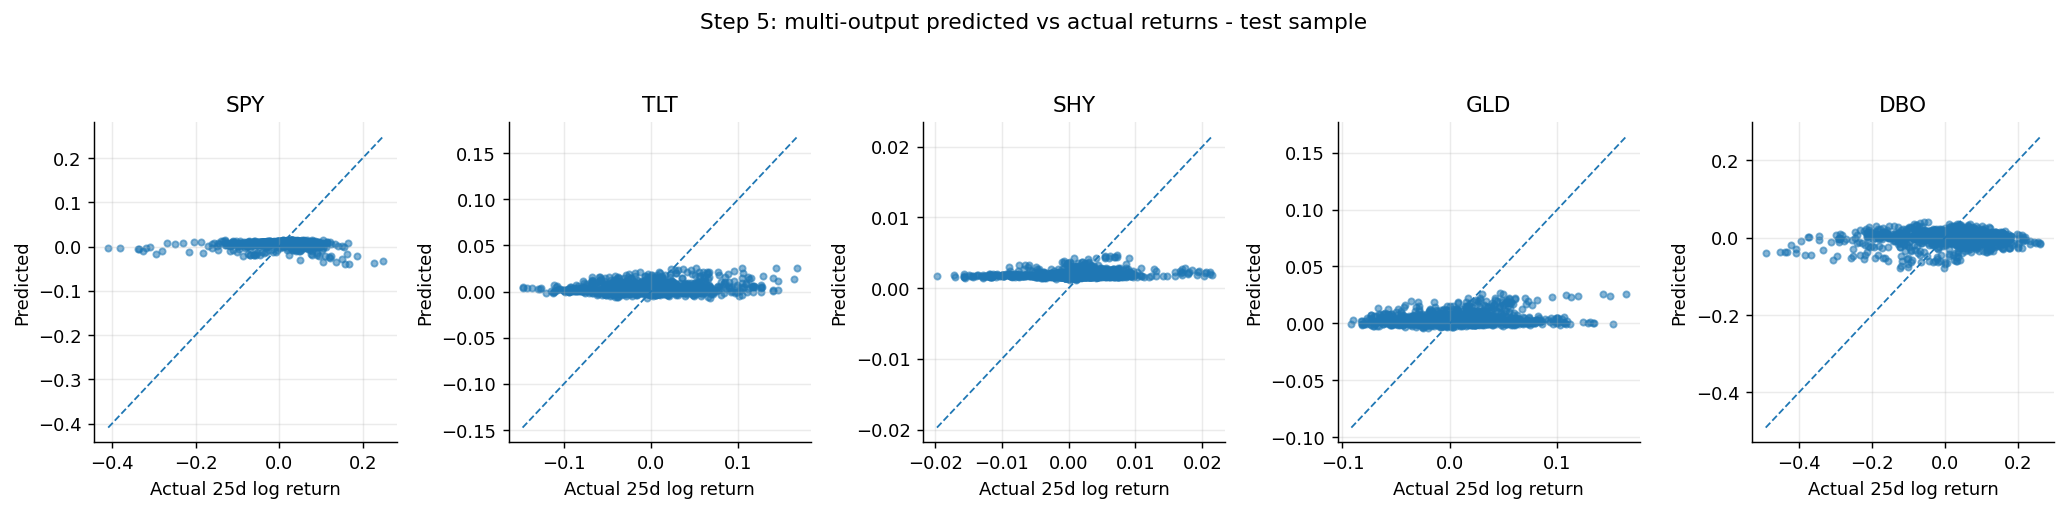

In [94]:
fig, ax = plt.subplots(figsize=(9, 4))
step5_test_compare.pivot_table(index='Ticker', columns='Architecture', values='Corr').reindex(ASSETS).plot(kind='bar', ax=ax)
ax.set_title('Step 5: test correlation by LSTM information set')
ax.set_xlabel('ETF')
ax.set_ylabel('Correlation')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 5, figsize=(16, 3.7))
for i, ticker in enumerate(ASSETS):
    y_true = multi_actual_test[ticker]
    y_pred = multi_pred_test[ticker].reindex(y_true.index)
    axes[i].scatter(y_true, y_pred, s=12, alpha=0.55)
    lo = np.nanmin([y_true.min(), y_pred.min()])
    hi = np.nanmax([y_true.max(), y_pred.max()])
    axes[i].plot([lo, hi], [lo, hi], linestyle='--', linewidth=1)
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Actual 25d log return')
    axes[i].set_ylabel('Predicted')
    axes[i].grid(True, alpha=0.25)
plt.suptitle('Step 5: multi-output predicted vs actual returns - test sample', y=1.05)
plt.tight_layout()
plt.show()

Ticker,SPY,TLT,SHY,GLD,DBO
Ticker,,,,,
SPY,1.0000,-0.4480,-0.4020,0.0350,0.4240
TLT,-0.4480,1.0000,0.5350,0.1080,-0.3110
SHY,-0.4020,0.5350,1.0000,0.1340,-0.1550
GLD,0.0350,0.1080,0.1340,1.0000,0.2510
DBO,0.4240,-0.3110,-0.1550,0.2510,1.0000


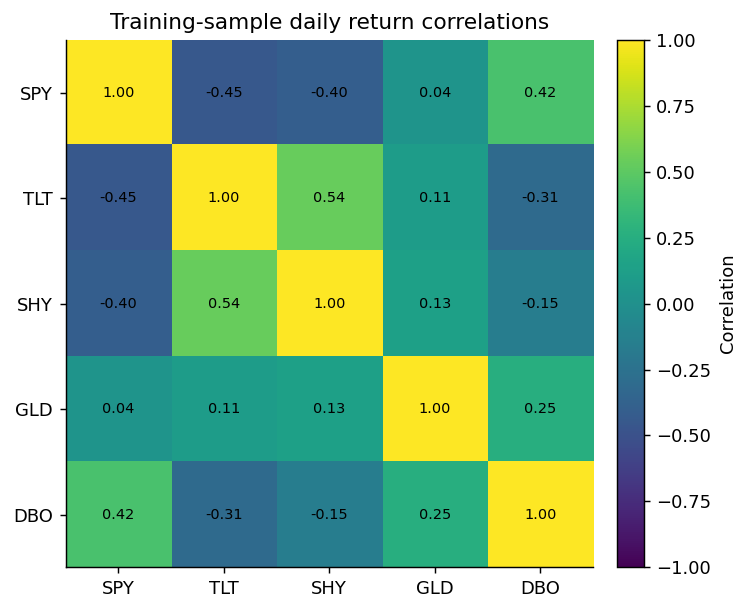

Step 5 discussion
- The Step 4 LSTMs and the Step 5 multi-output LSTM are not using the same information set.
- Step 4 conditions on each ETF's own lagged returns only; Step 5 conditions on the joint lagged return matrix of all five ETFs and optimizes a joint five-output loss.
- This lets the multi-output model use cross-asset information such as equity-bond, gold-rate, cash-duration, and oil-risk relationships.
- Test correlation improved versus Step 4 for: DBO, GLD, SHY, SPY, TLT.
- Test correlation did not improve versus Step 4 for: none.


,Corr_all_input_single,Corr_multi,Multi minus all-input single
Ticker,,,
DBO,0.1028,0.1076,0.0048
GLD,0.1751,0.1895,0.0144
SHY,-0.1733,0.1998,0.3732
SPY,0.1445,0.0053,-0.1392
TLT,-0.0514,0.1673,0.2188


- Relative to the all-input single-output control, the joint output loss helped most clearly for: DBO, GLD, SHY, TLT.
- The performance comparison is evidence consistent with cross-asset dependency learning, not proof. The all-input single-output control helps identify whether gains come from the wider input set or from the shared multi-output representation.


In [ ]:
# Step 5.4 Cross-asset dependency evidence and discussion

train_corr = lstm_returns.loc[:TRAIN_END_TS, ASSETS].corr()
display(train_corr.round(3))

fig, ax = plt.subplots(figsize=(5.7, 4.8))
im = ax.imshow(train_corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(ASSETS)))
ax.set_yticks(range(len(ASSETS)))
ax.set_xticklabels(ASSETS)
ax.set_yticklabels(ASSETS)
ax.set_title('Training-sample daily return correlations')
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        ax.text(j, i, f"{train_corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
plt.tight_layout()
plt.show()

improved = step45_delta.index[step45_delta['Corr change'] > 0].tolist()
worsened = step45_delta.index[step45_delta['Corr change'] <= 0].tolist()

print('Step 5 discussion')
print('- The Step 4 LSTMs and the Step 5 multi-output LSTM are not using the same information set.')
print('- Step 4 conditions on each ETF\'s own lagged returns only; Step 5 conditions on the joint lagged return matrix of all five ETFs and optimizes a joint five-output loss.')
print('- This lets the multi-output model use cross-asset information such as equity-bond, gold-rate, cash-duration, and oil-risk relationships.')
print(f"- Test correlation improved versus Step 4 for: {', '.join(improved) if improved else 'none'}.")
print(f"- Test correlation did not improve versus Step 4 for: {', '.join(worsened) if worsened else 'none'}.")

if RUN_STEP5_ABLATION and not xasset_single_df.empty:
    all_input_test = xasset_single_df.xs('Test', level='Split')
    tmp = all_input_test[['Corr']].join(multi_test[['Corr']], lsuffix='_all_input_single', rsuffix='_multi')
    tmp['Multi minus all-input single'] = tmp['Corr_multi'] - tmp['Corr_all_input_single']
    display(tmp.round(4))
    better_joint = tmp.index[tmp['Multi minus all-input single'] > 0].tolist()
    print(f"- Relative to the all-input single-output control, the joint output loss helped most clearly for: {', '.join(better_joint) if better_joint else 'none'}.")

print('- The performance comparison is evidence consistent with cross-asset dependency learning, not proof. The all-input single-output control helps identify whether gains come from the wider input set or from the shared multi-output representation.')

---
# STEP 6 - Backtest of the multi-output allocation strategy

The strategy ranks the five Step 5 predictions every 25 trading days, goes long the top two ETFs and short the bottom two ETFs, and compares the resulting out-of-sample performance with an equally weighted buy-and-hold portfolio.

In [ ]:
# Step 6.1 Backtest functions

def rank_weights(pred_row, long_n=2, short_n=2, gross=1.0, min_assets=4):
    s = pred_row.dropna().sort_values()
    if len(s) < min_assets or len(s) < long_n + short_n:
        return None

    w = pd.Series(0.0, index=ASSETS)
    short_assets = s.index[:short_n]
    long_assets = s.index[-long_n:]
    w.loc[long_assets] = (gross / 2) / long_n
    w.loc[short_assets] = -(gross / 2) / short_n
    return w


def prediction_backtest(pred_df, price_df, rebalance=25, cost_bps=0.0,
                        long_n=2, short_n=2, min_assets=4):
    px = price_df[ASSETS].dropna().loc[:TEST_END_TS]
    pred = pred_df.reindex(columns=ASSETS).dropna(how='all')
    pred = pred.loc[pred.index.intersection(px.index)].sort_index()
    signal_dates = pred.index[::rebalance]

    ret_blocks, weight_rows, turnover_rows = [], [], []
    prev_w = pd.Series(0.0, index=ASSETS)
    cost = cost_bps / 10000
    first_signal = None

    for d in signal_dates:
        w = rank_weights(pred.loc[d], long_n, short_n, 1.0, min_assets)
        if w is None:
            continue

        loc = px.index.get_loc(d)
        end_loc = min(loc + rebalance, len(px) - 1)
        if end_loc <= loc:
            continue

        entry = px.iloc[loc]
        hold_px = px.iloc[loc + 1:end_loc + 1]
        rel = hold_px.div(entry)
        value = 1 + rel.sub(1).dot(w)
        block_ret = value.pct_change()
        block_ret.iloc[0] = value.iloc[0] - 1

        turnover = (w - prev_w).abs().sum()
        block_ret.iloc[0] -= cost * turnover

        if first_signal is None:
            first_signal = d

        ret_blocks.append(block_ret.rename('return'))
        weight_rows.append(w.rename(d))
        turnover_rows.append({'Date': d, 'Turnover': turnover, 'Long': ', '.join(w[w > 0].index), 'Short': ', '.join(w[w < 0].index)})
        prev_w = w

    if not ret_blocks:
        raise RuntimeError('No strategy returns were generated.')

    rets = pd.concat(ret_blocks).sort_index()
    rets = rets[~rets.index.duplicated(keep='last')]
    rets = pd.concat([pd.Series([0.0], index=[first_signal], name='return'), rets]).sort_index()

    equity = (1 + rets).cumprod().rename('equity')
    weights = pd.DataFrame(weight_rows).fillna(0.0)
    turnover = pd.DataFrame(turnover_rows).set_index('Date')
    return rets, equity, weights, turnover


def equal_weight_buy_hold(price_df, start, end):
    px = price_df.loc[start:end, ASSETS].dropna()
    rel = px.div(px.iloc[0])
    equity = rel.mean(axis=1).rename('EW buy-and-hold')
    rets = equity.pct_change().fillna(0.0).rename('EW buy-and-hold')
    return rets, equity


def drawdown(equity):
    return equity.div(equity.cummax()).sub(1)


def perf_stats(daily_ret, name, turnover=None):
    r = daily_ret.dropna()
    equity = (1 + r).cumprod()
    n = len(r)
    ann_vol = r.std() * np.sqrt(252)
    sharpe = np.nan if ann_vol == 0 else (r.mean() / r.std()) * np.sqrt(252)
    dd = drawdown(equity)

    out = {
        'Strategy': name,
        'Start': r.index.min().date(),
        'End': r.index.max().date(),
        'Days': n,
        'Total Return': equity.iloc[-1] - 1,
        'Ann. Return': equity.iloc[-1] ** (252 / n) - 1,
        'Ann. Vol': ann_vol,
        'Sharpe (rf=0)': sharpe,
        'Max Drawdown': dd.min(),
        'Daily Win Rate': (r > 0).mean(),
    }
    if turnover is not None and not turnover.empty:
        out['Rebalances'] = len(turnover)
        out['Avg Turnover'] = turnover['Turnover'].mean()
    else:
        out['Rebalances'] = np.nan
        out['Avg Turnover'] = np.nan
    return out


def format_perf_table(df):
    out = df.copy()
    pct_cols = ['Total Return', 'Ann. Return', 'Ann. Vol', 'Max Drawdown', 'Daily Win Rate', 'Avg Turnover']
    for c in pct_cols:
        out[c] = out[c].map(lambda x: '' if pd.isna(x) else f'{x:.2%}')
    out['Sharpe (rf=0)'] = out['Sharpe (rf=0)'].map(lambda x: '' if pd.isna(x) else f'{x:.2f}')
    return out

In [ ]:
# Step 6.2 Run the out-of-sample backtests

TCOST_BPS = 0.0

multi_rets, multi_equity, multi_weights, multi_turnover = prediction_backtest(
    multi_pred_test, lstm_prices, rebalance=HORIZON, cost_bps=TCOST_BPS, min_assets=4
)

single_rets, single_equity, single_weights, single_turnover = prediction_backtest(
    single_pred_test_df, lstm_prices, rebalance=HORIZON, cost_bps=TCOST_BPS, min_assets=4
)

bt_start = multi_equity.index.min()
bt_end = multi_equity.index.max()
bench_rets, bench_equity = equal_weight_buy_hold(lstm_prices, bt_start, bt_end)

strategy_summary = pd.DataFrame([
    perf_stats(multi_rets.loc[bt_start:bt_end], 'Multi-output LSTM long-short', multi_turnover),
    perf_stats(single_rets.loc[bt_start:bt_end], 'Single-output LSTM long-short', single_turnover),
    perf_stats(bench_rets.loc[bt_start:bt_end], 'EW buy-and-hold', None),
])

display(format_perf_table(strategy_summary))
strategy_summary.to_csv(OUT_DIR / 'step6_strategy_summary.csv', index=False)
multi_weights.to_csv(OUT_DIR / 'step6_multi_strategy_weights.csv')
single_weights.to_csv(OUT_DIR / 'step6_single_strategy_weights.csv')
multi_turnover.to_csv(OUT_DIR / 'step6_multi_strategy_turnover.csv')

used_assets = multi_pred_test.reindex(multi_weights.index).notna().sum(axis=1)
print(f"Rebalance frequency: every {HORIZON} trading days")
print(f"Minimum number of prediction columns used: {int(used_assets.min())}")
print(f"Transaction cost assumption: {TCOST_BPS:.1f} bps per one-way turnover")
assert used_assets.min() >= 4
assert np.allclose(multi_weights.abs().sum(axis=1), 1.0)

,Strategy,Start,End,Days,Total Return,Ann. Return,Ann. Vol,Sharpe (rf=0),Max Drawdown,Daily Win Rate,Rebalances,Avg Turnover
0,Multi-output LSTM long-short,2018-01-02,2022-12-19,1251,35.19%,6.26%,11.73%,0.58,-20.28%,51.56%,50.0000,94.00%
1,Single-output LSTM long-short,2018-01-02,2022-12-19,1251,4.62%,0.91%,10.92%,0.14,-19.57%,49.80%,50.0000,92.00%
2,EW buy-and-hold,2018-01-02,2022-12-19,1251,26.12%,4.79%,10.18%,0.51,-16.91%,55.56%,NaN,


Rebalance frequency: every 25 trading days
Minimum number of prediction columns used: 5
Transaction cost assumption: 0.0 bps per one-way turnover


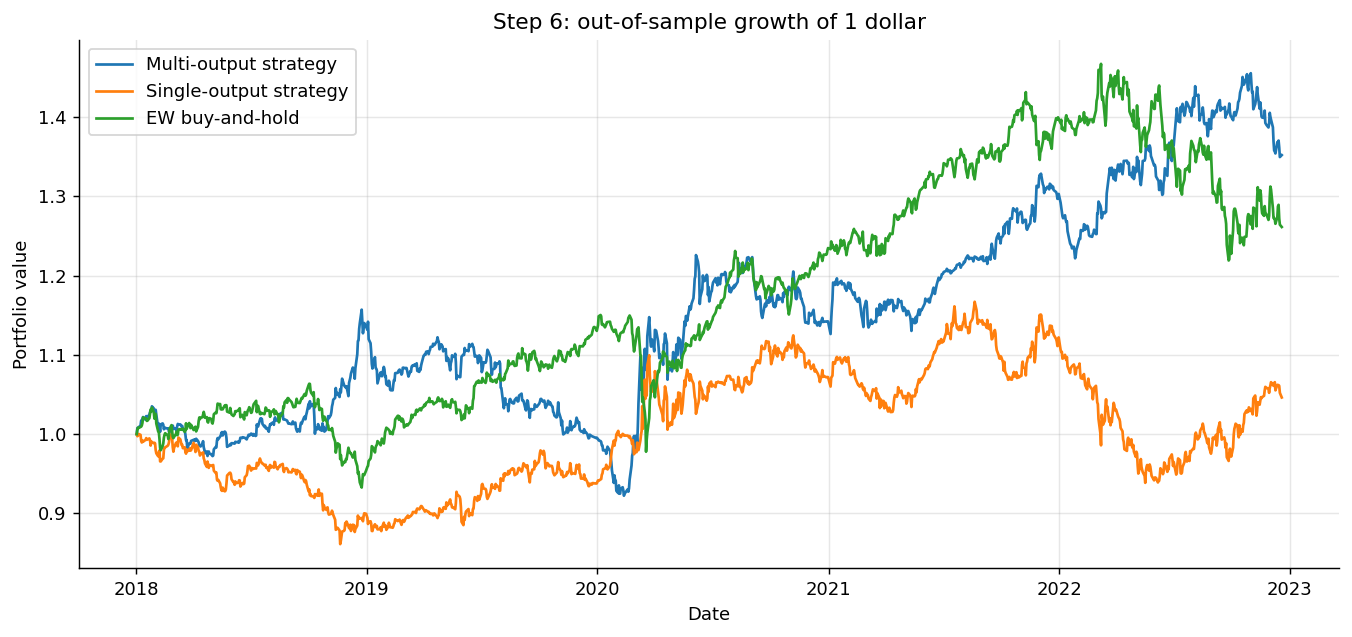

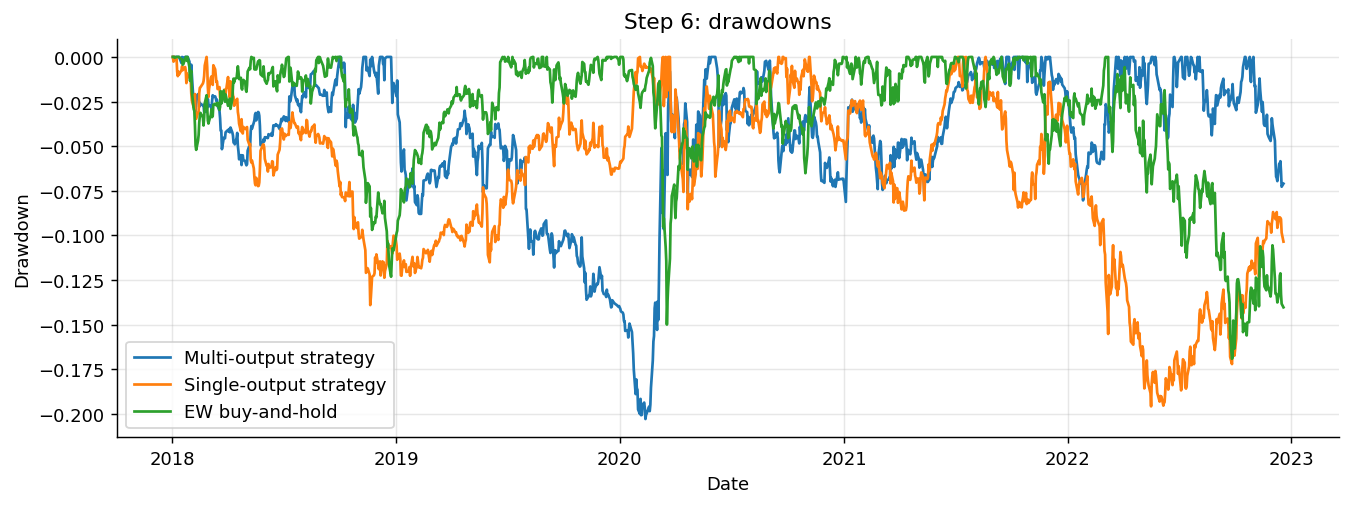

In [95]:
# Step 6.3 Backtest charts

curves = pd.concat([
    multi_equity.rename('Multi-output strategy'),
    single_equity.rename('Single-output strategy'),
    bench_equity.rename('EW buy-and-hold'),
], axis=1).ffill().dropna()

fig, ax = plt.subplots(figsize=(10.5, 5))
for col in curves.columns:
    ax.plot(curves.index, curves[col], label=col)
ax.set_title('Step 6: out-of-sample growth of 1 dollar')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step6_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

dds = curves.apply(drawdown)
fig, ax = plt.subplots(figsize=(10.5, 4))
for col in dds.columns:
    ax.plot(dds.index, dds[col], label=col)
ax.set_title('Step 6: drawdowns')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step6_drawdowns.png', dpi=150, bbox_inches='tight')
plt.show()


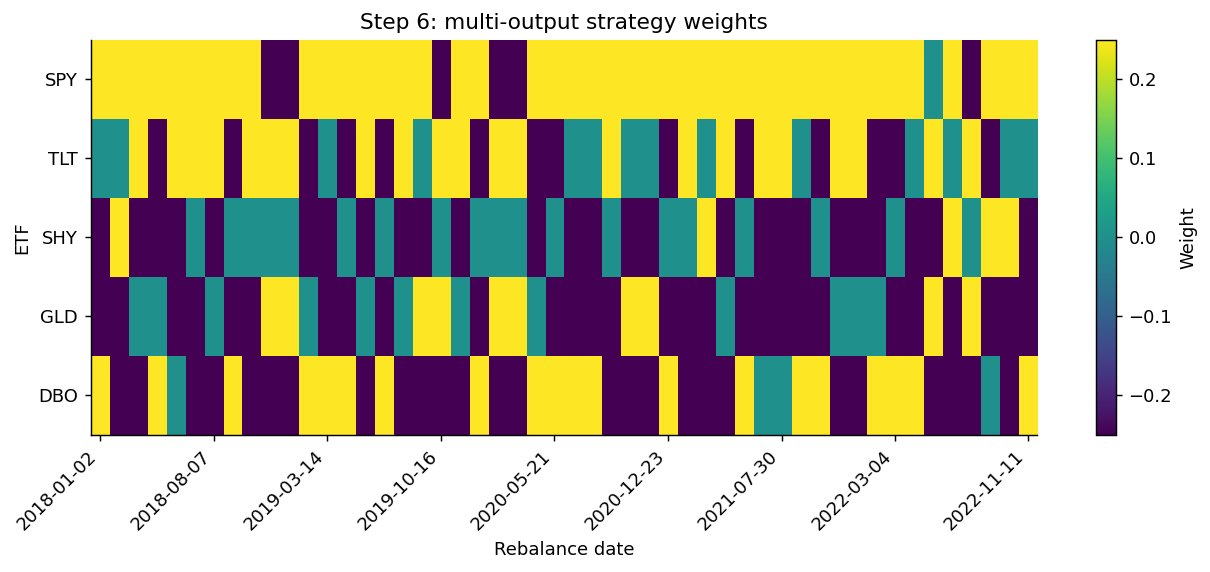

In [88]:

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(multi_weights.T, aspect='auto')
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels(ASSETS)
xticks = np.linspace(0, len(multi_weights.index) - 1, min(9, len(multi_weights.index))).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels([multi_weights.index[i].strftime('%Y-%m-%d') for i in xticks], rotation=45, ha='right')
ax.set_title('Step 6: multi-output strategy weights')
ax.set_xlabel('Rebalance date')
ax.set_ylabel('ETF')
plt.colorbar(im, ax=ax, label='Weight')
plt.tight_layout()
plt.savefig(OUT_DIR / 'step6_multi_weights.png', dpi=150, bbox_inches='tight')
plt.show()



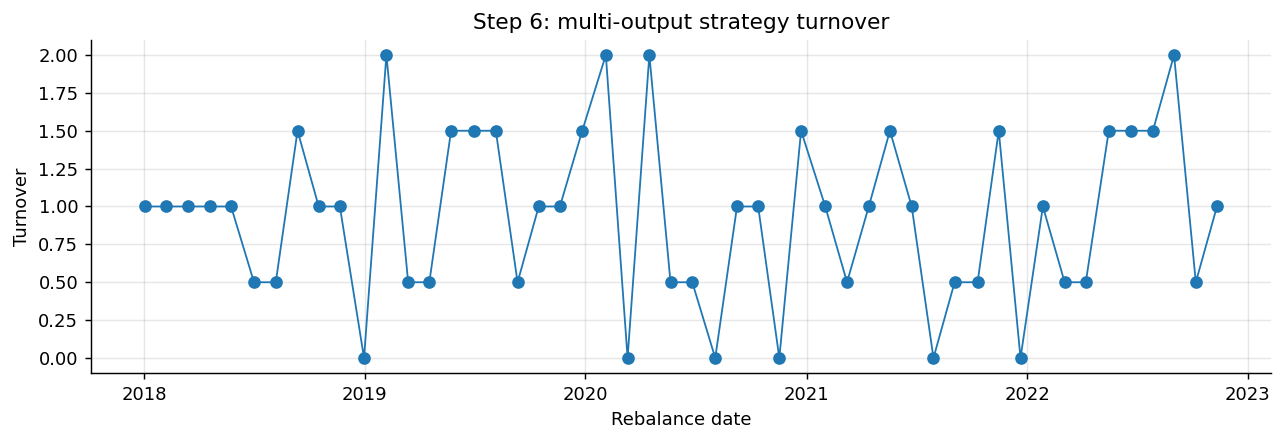

In [89]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(multi_turnover.index, multi_turnover['Turnover'], marker='o', linewidth=1)
ax.set_title('Step 6: multi-output strategy turnover')
ax.set_xlabel('Rebalance date')
ax.set_ylabel('Turnover')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step6_multi_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 6.4 Backtest notes and output files

multi_pred_test.to_csv(OUT_DIR / 'step5_multi_test_predictions.csv')
multi_actual_test.to_csv(OUT_DIR / 'step5_multi_test_actuals.csv')
single_pred_test_df.to_csv(OUT_DIR / 'step4_single_test_predictions.csv')
single_actual_test_df.to_csv(OUT_DIR / 'step4_single_test_actuals.csv')

summary_idx = strategy_summary.set_index('Strategy')
ms = summary_idx.loc['Multi-output LSTM long-short']
bh = summary_idx.loc['EW buy-and-hold']
ss = summary_idx.loc['Single-output LSTM long-short']

print('Step 6 Insights')
print(f"- The tradable prediction set contains all {len(ASSETS)} ETFs at each rebalance; the assignment requires at least 4.")
print(f"- The multi-output strategy is rebalanced every {HORIZON} trading days and positions are held from the next trading day.")
print(f"- Multi-output total return: {ms['Total Return']:.2%}; EW buy-and-hold total return: {bh['Total Return']:.2%}.")
print(f"- Multi-output Sharpe: {ms['Sharpe (rf=0)']:.2f}; EW buy-and-hold Sharpe: {bh['Sharpe (rf=0)']:.2f}.")
print(f"- Multi-output max drawdown: {ms['Max Drawdown']:.2%}; EW buy-and-hold max drawdown: {bh['Max Drawdown']:.2%}.")
print(f"- Optional isolation check: single-output LSTM strategy total return = {ss['Total Return']:.2%}, Sharpe = {ss['Sharpe (rf=0)']:.2f}.")
print('- Results exclude financing, borrow fees, bid-ask spreads, taxes, and market impact unless TCOST_BPS is changed.')
print(f"Saved Step 4-6 outputs to: {OUT_DIR}")

Step 6 notes
- The tradable prediction set contains all 5 ETFs at each rebalance; the assignment requires at least 4.
- The multi-output strategy is rebalanced every 25 trading days and positions are held from the next trading day.
- Multi-output total return: 35.19%; EW buy-and-hold total return: 26.12%.
- Multi-output Sharpe: 0.58; EW buy-and-hold Sharpe: 0.51.
- Multi-output max drawdown: -20.28%; EW buy-and-hold max drawdown: -16.91%.
- Optional isolation check: single-output LSTM strategy total return = 4.62%, Sharpe = 0.14.
- Results exclude financing, borrow fees, bid-ask spreads, taxes, and market impact unless TCOST_BPS is changed.
Saved Step 4-6 outputs to: /content/gwp1_step456_outputs
